# Historical notebook
Preserved for reference. Run the current workflow in `../prediction_bivariate.ipynb`.
Only the workspace setup and saved-model paths were updated during repository cleanup; original code and historical outputs are otherwise retained. These notebooks may require extra dependencies and contain known data-schema mismatches.


In [ ]:
from pathlib import Path
import os
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/prediction_bivariate.py").is_file())
os.chdir(PROJECT_ROOT / "data")


# Prediction #


In [1]:
import pandas as pd
import numpy as np
from sklearn import feature_selection
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
from sklearn import datasets, ensemble
from sklearn import metrics
from sklearn.metrics import mean_squared_error,roc_auc_score, accuracy_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression,LinearRegression, PoissonRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, IsolationForest
import pickle
import seaborn as sns

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
# we will see how this compares to betting odds auc

#FIX MATCHWEEK
train['Matchweek'] = train['Matchweek'].apply(lambda x: int(x.split()[-1]))
test['Matchweek'] = test['Matchweek'].apply(lambda x: int(x.split()[-1]))


In [3]:
betting_data = test[['B365A', 'B365D', 'B365H']]


In [4]:
train.drop(['Unnamed: 0'], axis=1, inplace=True)
test.drop(['Unnamed: 0'], axis=1, inplace=True)


In [5]:
# cols_to_keep = ['home_score','away_score','home_team_name', 'away_team_name',
#                 'HomePlayer_Overall_mean',  'AwayPlayer_Overall_mean', 
#                 'HomePlayer_Overall_sd',
#                 'AwayPlayer_Overall_sd','HomePlayer_Overall_mean_ln', 
#                 'AwayPlayer_Overall_mean_ln', 'HomePlayer_Overall_max', 'HomePlayer_Overall_min',
#                 'AwayPlayer_Overall_max', 'AwayPlayer_Overall_min',
#                 'home_GD_form_pw', 'away_GD_form_pw',
#                 'home_Points_form_pw', 'away_Points_form_pw',
#                  'home_points_to_championship',
#                 'home_points_to_ucl','home_points_to_rel','away_points_to_championship',
#                 'away_points_to_ucl','away_points_to_rel']
# train = train[cols_to_keep]
# test = test[cols_to_keep]

In [6]:
train["Home_min_max"] = train['HomePlayer_Overall_max'] * train['HomePlayer_Overall_min']
train['Away_min_max'] = train['AwayPlayer_Overall_max'] * train['AwayPlayer_Overall_min']

test["Home_min_max"] = test['HomePlayer_Overall_max'] * test['HomePlayer_Overall_min']
test['Away_min_max'] = test['AwayPlayer_Overall_max'] * test['AwayPlayer_Overall_min']

for col in train.columns:
    if 'bench' in col or 'points_to' in col:
        train.drop(col, axis=1, inplace=True)
        test.drop(col, axis=1, inplace=True)

In [7]:
# train['OvO'] = train['HomePlayer_Overall_mean'] - train['AwayPlayer_Overall_mean']
# train['OvO_sqrt'] = train['HomePlayer_Overall_mean_sqrt'] - train['AwayPlayer_Overall_mean_sqrt']
# train['OvO_ln'] = train['HomePlayer_Overall_mean_sqrt'] - train['AwayPlayer_Overall_mean_sqrt']

# test['OvO'] = test['HomePlayer_Overall_mean'] - test['AwayPlayer_Overall_mean']
# test['OvO_sqrt'] = test['HomePlayer_Overall_mean_sqrt'] - test['AwayPlayer_Overall_mean_sqrt']
# test['OvO_ln'] = test['HomePlayer_Overall_mean_sqrt'] - test['AwayPlayer_Overall_mean_sqrt']

# train.drop(['AwayPlayer_Overall_mean', 'HomePlayer_Overall_mean',
#             'AwayPlayer_Overall_mean_sqrt', 'HomePlayer_Overall_mean_sqrt',
#             'AwayPlayer_Overall_mean_ln', 'HomePlayer_Overall_mean_ln'], axis=1, inplace=True)
# test.drop(['AwayPlayer_Overall_mean', 'HomePlayer_Overall_mean',
#             'AwayPlayer_Overall_mean_sqrt', 'HomePlayer_Overall_mean_sqrt',
#             'AwayPlayer_Overall_mean_ln', 'HomePlayer_Overall_mean_ln'], axis=1, inplace=True)

Squaring Where Needed

In [8]:
# train

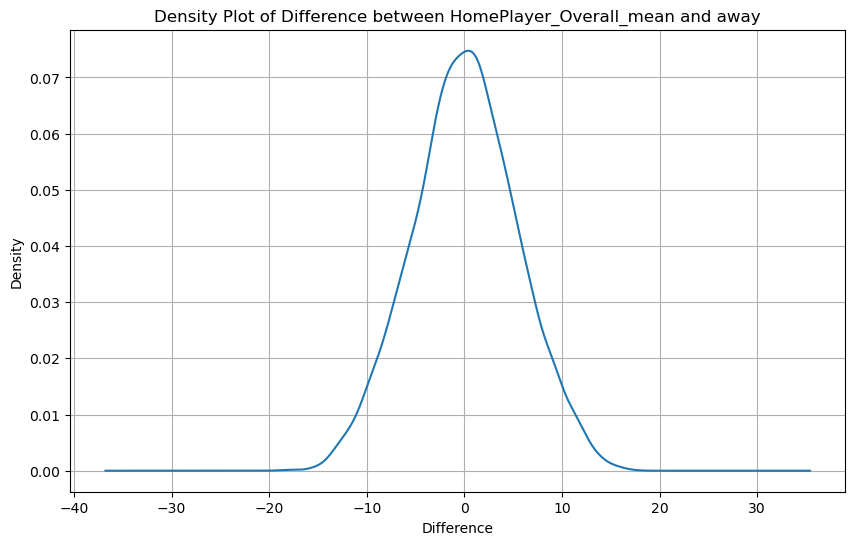

In [9]:
### Dealing with outliers

# Create a new column 'difference' which is the difference between 'HomePlayer_Overall_mean' and 'away'
train['difference'] = train['HomePlayer_Overall_mean'] - train['AwayPlayer_Overall_mean']

# Plot the density plot for the difference
plt.figure(figsize=(10, 6))  # Adjust figure size if needed
train['difference'].plot(kind='density')
plt.title('Density Plot of Difference between HomePlayer_Overall_mean and away')
plt.xlabel('Difference')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [10]:

# # Calculate the percentile values
# lower_percentile = train['difference'].quantile(0.025)
# upper_percentile = train['difference'].quantile(0.975)

# # Filter the data to remove bottom 2.5% and top 2.5%
# filtered_data = train[(train['difference'] >= lower_percentile) & (train['difference'] <= upper_percentile)]

train.drop('difference', axis=1, inplace=True)

In [11]:
train_back_up = train.copy()
test_back_up = test.copy()

In [12]:
#fixing the order of columns
test = test[train.columns]

In [13]:
print(set(list(test['home_team_name'])+list( train['home_team_name'])))

{'Brentford', 'Lecce', 'Schalke 04', 'Eibar', 'Newcastle United', 'Las Palmas', 'Carpi', 'Southampton', 'Ingolstadt 04', 'Arminia', 'Queens Park Rangers', 'Atlético Madrid', 'Torino', 'Sunderland', 'Roma', 'Crystal Palace', 'Leverkusen', 'West Bromwich Albion', 'Girona', 'Palermo', 'Athletic Club', 'Union Berlin', 'Bayern Munich', 'Nottingham Forest', 'Elche', 'Spezia', 'Fiorentina', 'Hoffenheim', 'Rayo Vallecano', 'Genoa', 'Bochum', 'Hertha BSC', 'AFC Bournemouth', 'Swansea City', 'Cardiff City', 'Almería', 'Werder Bremen', 'Brighton & Hove Albion', 'West Ham United', 'Barcelona', 'Atalanta', 'Valladolid', 'Everton', 'Villarreal', 'Real Sociedad', 'La Coruña', 'Cagliari', 'Bologna', 'Eint Frankfurt', 'Napoli', 'Sevilla', 'Hull City', 'Getafe', 'Mainz 05', 'Alavés', 'Chievo', 'Frosinone', 'Sassuolo', 'Sheffield United', 'Wolfsburg', 'Norwich City', 'Düsseldorf', 'Monza', 'Brescia', 'Leicester City', 'Paderborn 07', 'Middlesbrough', 'Sampdoria', 'Cremonese', 'Espanyol', 'Arsenal', 'Cádi

In [14]:
# # Initialize the OneHotEncoder with handle_unknown='ignore'

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# One-hot encode 'home_team_name'
encoded = encoder.fit_transform(train[['home_team_name', 'away_team_name', 'league']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['home_team_name', 'away_team_name','league']))
encoded_test = encoder.transform(test[['home_team_name', 'away_team_name', 'league']])
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(['home_team_name', 'away_team_name', 'league']))
with open('../models/legacy/encoder', 'wb') as f:
    pickle.dump(encoder, f)
# Concatenate the encoded columns with the original DataFrame
train = pd.concat([encoded_df, train], axis=1)
test = pd.concat([encoded_test_df, test], axis=1)

train.drop(['home_team_name', 'away_team_name', 'league'], axis=1, inplace=True)
test.drop(['home_team_name', 'away_team_name', 'league'], axis=1, inplace=True)

test = test[train.columns]


In [15]:
# Display rows with NA values in test DataFrame
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
train[train.isna().any(axis=1)]



,home_team_name_AFC Bournemouth,home_team_name_Alavés,home_team_name_Almería,home_team_name_Arminia,home_team_name_Arsenal,home_team_name_Aston Villa,home_team_name_Atalanta,home_team_name_Athletic Club,home_team_name_Atlético Madrid,home_team_name_Augsburg,home_team_name_Barcelona,home_team_name_Bayern Munich,home_team_name_Benevento,home_team_name_Betis,home_team_name_Bochum,home_team_name_Bologna,home_team_name_Brentford,home_team_name_Brescia,home_team_name_Brighton & Hove Albion,home_team_name_Burnley,home_team_name_Cagliari,home_team_name_Cardiff City,home_team_name_Carpi,home_team_name_Celta Vigo,home_team_name_Cesena,home_team_name_Chelsea,home_team_name_Chievo,home_team_name_Crotone,home_team_name_Crystal Palace,home_team_name_Cádiz,home_team_name_Córdoba,home_team_name_Darmstadt 98,home_team_name_Dortmund,home_team_name_Düsseldorf,home_team_name_Eibar,home_team_name_Eint Frankfurt,home_team_name_Elche,home_team_name_Empoli,home_team_name_Espanyol,home_team_name_Everton,home_team_name_Fiorentina,home_team_name_Freiburg,home_team_name_Frosinone,home_team_name_Fulham,home_team_name_Genoa,home_team_name_Getafe,home_team_name_Girona,home_team_name_Gladbach,home_team_name_Granada,home_team_name_Greuther Fürth,home_team_name_Hamburger SV,home_team_name_Hannover 96,home_team_name_Hellas Verona,home_team_name_Hertha BSC,home_team_name_Hoffenheim,home_team_name_Huddersfield Town,home_team_name_Huesca,home_team_name_Hull City,home_team_name_Ingolstadt 04,home_team_name_Inter,home_team_name_Juventus,home_team_name_Köln,home_team_name_La Coruña,home_team_name_Las Palmas,home_team_name_Lazio,home_team_name_Lecce,home_team_name_Leeds United,home_team_name_Leganés,home_team_name_Leicester City,home_team_name_Levante,home_team_name_Leverkusen,home_team_name_Liverpool,home_team_name_Mainz 05,home_team_name_Mallorca,home_team_name_Manchester City,home_team_name_Manchester United,home_team_name_Middlesbrough,home_team_name_Milan,home_team_name_Málaga,home_team_name_Napoli,home_team_name_Newcastle United,home_team_name_Norwich City,home_team_name_Nürnberg,home_team_name_Osasuna,home_team_name_Paderborn 07,home_team_name_Palermo,home_team_name_Parma,home_team_name_Pescara,home_team_name_Queens Park Rangers,home_team_name_RB Leipzig,home_team_name_Rayo Vallecano,home_team_name_Real Madrid,home_team_name_Real Sociedad,home_team_name_Roma,home_team_name_SPAL,home_team_name_Salernitana,home_team_name_Sampdoria,home_team_name_Sassuolo,home_team_name_Schalke 04,home_team_name_Sevilla,home_team_name_Sheffield United,home_team_name_Southampton,home_team_name_Spezia,home_team_name_Sporting Gijón,home_team_name_Stoke City,home_team_name_Stuttgart,home_team_name_Sunderland,home_team_name_Swansea City,home_team_name_Torino,home_team_name_Tottenham Hotspur,home_team_name_Udinese,home_team_name_Union Berlin,home_team_name_Valencia,home_team_name_Valladolid,home_team_name_Venezia,home_team_name_Villarreal,home_team_name_Watford,home_team_name_Werder Bremen,home_team_name_West Bromwich Albion,home_team_name_West Ham United,home_team_name_Wolfsburg,home_team_name_Wolverhampton Wanderers,away_team_name_AFC Bournemouth,away_team_name_Alavés,away_team_name_Almería,away_team_name_Arminia,away_team_name_Arsenal,away_team_name_Aston Villa,away_team_name_Atalanta,away_team_name_Athletic Club,away_team_name_Atlético Madrid,away_team_name_Augsburg,away_team_name_Barcelona,away_team_name_Bayern Munich,away_team_name_Benevento,away_team_name_Betis,away_team_name_Bochum,away_team_name_Bologna,away_team_name_Brentford,away_team_name_Brescia,away_team_name_Brighton & Hove Albion,away_team_name_Burnley,away_team_name_Cagliari,away_team_name_Cardiff City,away_team_name_Carpi,away_team_name_Celta Vigo,away_team_name_Cesena,away_team_name_Chelsea,away_team_name_Chievo,away_team_name_Crotone,away_team_name_Crystal Palace,away_team_name_Cádiz,away_team_name_Córdoba,away_team_name_Darmstadt 98,away_team_name_Dortmund,away_team_name_Düsseldorf,away_team_name_Eibar,away_team_na

In [16]:
test.dropna(inplace=True)
train.dropna(inplace=True)

#print for sanity check

print(test.shape)
print(train.shape)

(1447, 280)
(11561, 280)


In [17]:
train.head()

,home_team_name_AFC Bournemouth,home_team_name_Alavés,home_team_name_Almería,home_team_name_Arminia,home_team_name_Arsenal,home_team_name_Aston Villa,home_team_name_Atalanta,home_team_name_Athletic Club,home_team_name_Atlético Madrid,home_team_name_Augsburg,home_team_name_Barcelona,home_team_name_Bayern Munich,home_team_name_Benevento,home_team_name_Betis,home_team_name_Bochum,home_team_name_Bologna,home_team_name_Brentford,home_team_name_Brescia,home_team_name_Brighton & Hove Albion,home_team_name_Burnley,home_team_name_Cagliari,home_team_name_Cardiff City,home_team_name_Carpi,home_team_name_Celta Vigo,home_team_name_Cesena,home_team_name_Chelsea,home_team_name_Chievo,home_team_name_Crotone,home_team_name_Crystal Palace,home_team_name_Cádiz,home_team_name_Córdoba,home_team_name_Darmstadt 98,home_team_name_Dortmund,home_team_name_Düsseldorf,home_team_name_Eibar,home_team_name_Eint Frankfurt,home_team_name_Elche,home_team_name_Empoli,home_team_name_Espanyol,home_team_name_Everton,home_team_name_Fiorentina,home_team_name_Freiburg,home_team_name_Frosinone,home_team_name_Fulham,home_team_name_Genoa,home_team_name_Getafe,home_team_name_Girona,home_team_name_Gladbach,home_team_name_Granada,home_team_name_Greuther Fürth,home_team_name_Hamburger SV,home_team_name_Hannover 96,home_team_name_Hellas Verona,home_team_name_Hertha BSC,home_team_name_Hoffenheim,home_team_name_Huddersfield Town,home_team_name_Huesca,home_team_name_Hull City,home_team_name_Ingolstadt 04,home_team_name_Inter,home_team_name_Juventus,home_team_name_Köln,home_team_name_La Coruña,home_team_name_Las Palmas,home_team_name_Lazio,home_team_name_Lecce,home_team_name_Leeds United,home_team_name_Leganés,home_team_name_Leicester City,home_team_name_Levante,home_team_name_Leverkusen,home_team_name_Liverpool,home_team_name_Mainz 05,home_team_name_Mallorca,home_team_name_Manchester City,home_team_name_Manchester United,home_team_name_Middlesbrough,home_team_name_Milan,home_team_name_Málaga,home_team_name_Napoli,home_team_name_Newcastle United,home_team_name_Norwich City,home_team_name_Nürnberg,home_team_name_Osasuna,home_team_name_Paderborn 07,home_team_name_Palermo,home_team_name_Parma,home_team_name_Pescara,home_team_name_Queens Park Rangers,home_team_name_RB Leipzig,home_team_name_Rayo Vallecano,home_team_name_Real Madrid,home_team_name_Real Sociedad,home_team_name_Roma,home_team_name_SPAL,home_team_name_Salernitana,home_team_name_Sampdoria,home_team_name_Sassuolo,home_team_name_Schalke 04,home_team_name_Sevilla,home_team_name_Sheffield United,home_team_name_Southampton,home_team_name_Spezia,home_team_name_Sporting Gijón,home_team_name_Stoke City,home_team_name_Stuttgart,home_team_name_Sunderland,home_team_name_Swansea City,home_team_name_Torino,home_team_name_Tottenham Hotspur,home_team_name_Udinese,home_team_name_Union Berlin,home_team_name_Valencia,home_team_name_Valladolid,home_team_name_Venezia,home_team_name_Villarreal,home_team_name_Watford,home_team_name_Werder Bremen,home_team_name_West Bromwich Albion,home_team_name_West Ham United,home_team_name_Wolfsburg,home_team_name_Wolverhampton Wanderers,away_team_name_AFC Bournemouth,away_team_name_Alavés,away_team_name_Almería,away_team_name_Arminia,away_team_name_Arsenal,away_team_name_Aston Villa,away_team_name_Atalanta,away_team_name_Athletic Club,away_team_name_Atlético Madrid,away_team_name_Augsburg,away_team_name_Barcelona,away_team_name_Bayern Munich,away_team_name_Benevento,away_team_name_Betis,away_team_name_Bochum,away_team_name_Bologna,away_team_name_Brentford,away_team_name_Brescia,away_team_name_Brighton & Hove Albion,away_team_name_Burnley,away_team_name_Cagliari,away_team_name_Cardiff City,away_team_name_Carpi,away_team_name_Celta Vigo,away_team_name_Cesena,away_team_name_Chelsea,away_team_name_Chievo,away_team_name_Crotone,away_team_name_Crystal Palace,away_team_name_Cádiz,away_team_name_Córdoba,away_team_name_Darmstadt 98,away_team_name_Dortmund,away_team_name_Düsseldorf,away_team_name_Eibar,away_team_na

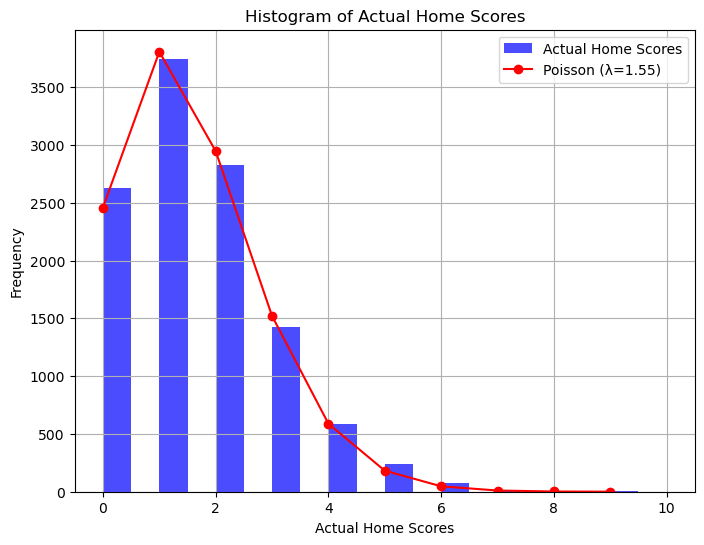

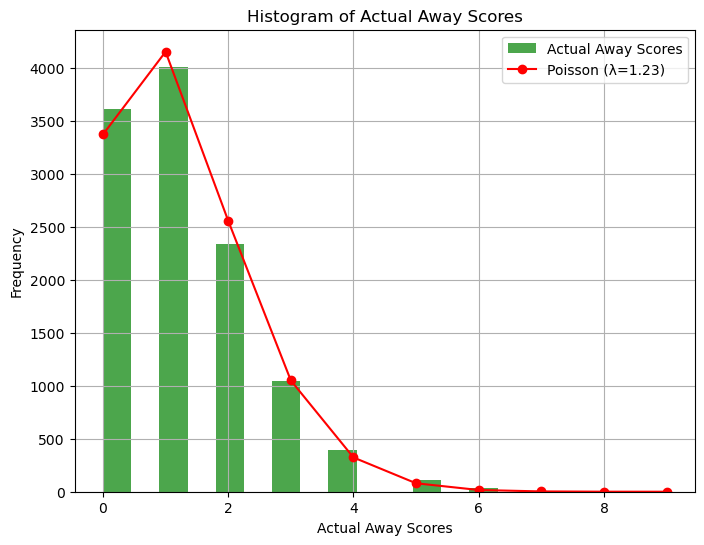

In [18]:
from scipy.stats import poisson

# Plot histogram for actual home scores
plt.figure(figsize=(8, 6))
plt.hist(train['home_score'], bins=20, color='blue', alpha=0.7, label='Actual Home Scores', density=False)
plt.xlabel('Actual Home Scores')
plt.ylabel('Frequency')
plt.title('Histogram of Actual Home Scores')

# Calculate mean for home scores
mean_home_score = np.mean(train['home_score'])

# Generate Poisson distribution for home scores
x_home = np.arange(0, 10)
poisson_home = poisson.pmf(x_home, mean_home_score) * len(train['home_score'])
plt.plot(x_home, poisson_home, '-o', color='red', label='Poisson (λ={:.2f})'.format(mean_home_score))

plt.legend()
plt.grid(True)
plt.show()

# Plot histogram for actual away scores
plt.figure(figsize=(8, 6))
plt.hist(train['away_score'], bins=20, color='green', alpha=0.7, label='Actual Away Scores', density=False)
plt.xlabel('Actual Away Scores')
plt.ylabel('Frequency')
plt.title('Histogram of Actual Away Scores')

# Calculate mean for away scores
mean_away_score = np.mean(train['away_score'])

# Generate Poisson distribution for away scores
x_away = np.arange(0, 10)
poisson_away = poisson.pmf(x_away, mean_away_score) * len(train['away_score'])
plt.plot(x_away, poisson_away, '-o', color='red', label='Poisson (λ={:.2f})'.format(mean_away_score))

plt.legend()
plt.grid(True)
plt.show()

In [19]:
train['label'] = 1
test['label'] = 1

train['GD'] = train['home_score'] - train['away_score']
test['GD'] = test['home_score'] - test['away_score']
#try later with both poisson and different regressions
ytrain_home = train['home_score']
ytrain_away = train['away_score']

ytest_home = test['home_score']
ytest_away = test['away_score']
# Dropping the columns


train.drop(['home_score', 'away_score'], axis=1, inplace=True)
test.drop(['home_score', 'away_score'], axis=1, inplace=True)


train.loc[train['GD'] > 0, 'label'] = 2
test.loc[test['GD'] > 0, 'label'] = 2


train.loc[train['GD'] < 0, 'label'] = 0

test.loc[test['GD'] < 0, 'label'] = 0


# Saving the gd as y_reg (y regression)

y_train_reg = train['GD']
y_test_reg = test['GD']

y_train = train['label']
y_test = test['label']




train.drop(['GD', 'label'], axis=1, inplace=True)
test.drop(['GD', 'label'], axis=1, inplace=True)


In [20]:
def get_versus(df, attributes, statistics):
    versus_df = pd.DataFrame()
    for att in attributes:
        for stat in statistics:
            versus_df[att+'_'+att+"__"+stat] = df['HomePlayer_'+att+'_'+stat] - df['AwayPlayer_'+att+'_'+stat]
    return versus_df

In [21]:
train.dropna(axis=0).shape

(11561, 278)

In [22]:
train.shape

(11561, 278)

In [23]:
train.head()

,home_team_name_AFC Bournemouth,home_team_name_Alavés,home_team_name_Almería,home_team_name_Arminia,home_team_name_Arsenal,home_team_name_Aston Villa,home_team_name_Atalanta,home_team_name_Athletic Club,home_team_name_Atlético Madrid,home_team_name_Augsburg,home_team_name_Barcelona,home_team_name_Bayern Munich,home_team_name_Benevento,home_team_name_Betis,home_team_name_Bochum,home_team_name_Bologna,home_team_name_Brentford,home_team_name_Brescia,home_team_name_Brighton & Hove Albion,home_team_name_Burnley,home_team_name_Cagliari,home_team_name_Cardiff City,home_team_name_Carpi,home_team_name_Celta Vigo,home_team_name_Cesena,home_team_name_Chelsea,home_team_name_Chievo,home_team_name_Crotone,home_team_name_Crystal Palace,home_team_name_Cádiz,home_team_name_Córdoba,home_team_name_Darmstadt 98,home_team_name_Dortmund,home_team_name_Düsseldorf,home_team_name_Eibar,home_team_name_Eint Frankfurt,home_team_name_Elche,home_team_name_Empoli,home_team_name_Espanyol,home_team_name_Everton,home_team_name_Fiorentina,home_team_name_Freiburg,home_team_name_Frosinone,home_team_name_Fulham,home_team_name_Genoa,home_team_name_Getafe,home_team_name_Girona,home_team_name_Gladbach,home_team_name_Granada,home_team_name_Greuther Fürth,home_team_name_Hamburger SV,home_team_name_Hannover 96,home_team_name_Hellas Verona,home_team_name_Hertha BSC,home_team_name_Hoffenheim,home_team_name_Huddersfield Town,home_team_name_Huesca,home_team_name_Hull City,home_team_name_Ingolstadt 04,home_team_name_Inter,home_team_name_Juventus,home_team_name_Köln,home_team_name_La Coruña,home_team_name_Las Palmas,home_team_name_Lazio,home_team_name_Lecce,home_team_name_Leeds United,home_team_name_Leganés,home_team_name_Leicester City,home_team_name_Levante,home_team_name_Leverkusen,home_team_name_Liverpool,home_team_name_Mainz 05,home_team_name_Mallorca,home_team_name_Manchester City,home_team_name_Manchester United,home_team_name_Middlesbrough,home_team_name_Milan,home_team_name_Málaga,home_team_name_Napoli,home_team_name_Newcastle United,home_team_name_Norwich City,home_team_name_Nürnberg,home_team_name_Osasuna,home_team_name_Paderborn 07,home_team_name_Palermo,home_team_name_Parma,home_team_name_Pescara,home_team_name_Queens Park Rangers,home_team_name_RB Leipzig,home_team_name_Rayo Vallecano,home_team_name_Real Madrid,home_team_name_Real Sociedad,home_team_name_Roma,home_team_name_SPAL,home_team_name_Salernitana,home_team_name_Sampdoria,home_team_name_Sassuolo,home_team_name_Schalke 04,home_team_name_Sevilla,home_team_name_Sheffield United,home_team_name_Southampton,home_team_name_Spezia,home_team_name_Sporting Gijón,home_team_name_Stoke City,home_team_name_Stuttgart,home_team_name_Sunderland,home_team_name_Swansea City,home_team_name_Torino,home_team_name_Tottenham Hotspur,home_team_name_Udinese,home_team_name_Union Berlin,home_team_name_Valencia,home_team_name_Valladolid,home_team_name_Venezia,home_team_name_Villarreal,home_team_name_Watford,home_team_name_Werder Bremen,home_team_name_West Bromwich Albion,home_team_name_West Ham United,home_team_name_Wolfsburg,home_team_name_Wolverhampton Wanderers,away_team_name_AFC Bournemouth,away_team_name_Alavés,away_team_name_Almería,away_team_name_Arminia,away_team_name_Arsenal,away_team_name_Aston Villa,away_team_name_Atalanta,away_team_name_Athletic Club,away_team_name_Atlético Madrid,away_team_name_Augsburg,away_team_name_Barcelona,away_team_name_Bayern Munich,away_team_name_Benevento,away_team_name_Betis,away_team_name_Bochum,away_team_name_Bologna,away_team_name_Brentford,away_team_name_Brescia,away_team_name_Brighton & Hove Albion,away_team_name_Burnley,away_team_name_Cagliari,away_team_name_Cardiff City,away_team_name_Carpi,away_team_name_Celta Vigo,away_team_name_Cesena,away_team_name_Chelsea,away_team_name_Chievo,away_team_name_Crotone,away_team_name_Crystal Palace,away_team_name_Cádiz,away_team_name_Córdoba,away_team_name_Darmstadt 98,away_team_name_Dortmund,away_team_name_Düsseldorf,away_team_name_Eibar,away_team_na

In [24]:
to_log = ['Overall', 'Height', 'Weight']
'''
for col in train.columns:
    for t in to_log:
        if t in col:
            train[col] = np.log2(train[col])
            test[col] = np.log2(test[col])
'''
#versus_train = get_versus(train, to_log, ['mean','min','max','sd'])
#versus_test = get_versus(test, to_log, ['mean','min','max','sd'])


'\nfor col in train.columns:\n    for t in to_log:\n        if t in col:\n            train[col] = np.log2(train[col])\n            test[col] = np.log2(test[col])\n'

In [25]:
for col in train.columns:
    if col not in test.columns:
        print(col)
        print(test.columns)

In [26]:
train.to_csv('X_train.csv')
y_train.to_csv("Y_train.csv")
test.to_csv('X_test.csv')
y_test.to_csv("Y_test.csv")


In [27]:

# Standardize the data for numeric columns
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train)
train_scaled = pd.DataFrame(train_scaled, columns=train.columns)

test_scaled = scaler.transform(test)
test_scaled = pd.DataFrame(test_scaled, columns=test.columns)


Text(0, 0.5, 'Density')

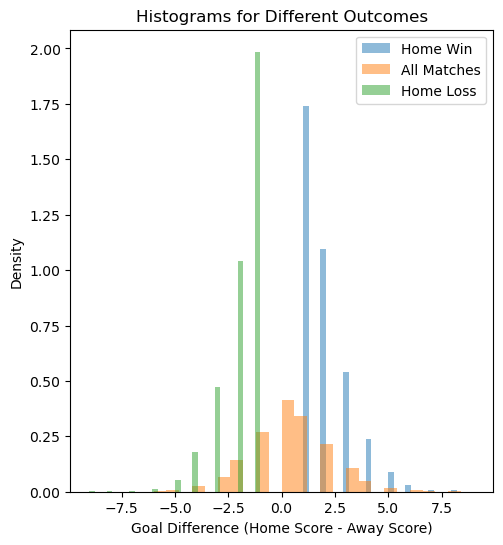

In [28]:

# Separate the data based on labels
home_win_data = y_train_reg[y_train == 2]
home_loss = y_train_reg[y_train == 0]

# Create histograms
plt.figure(figsize=(12, 6))

# Plot histograms
plt.subplot(1, 2, 1)
plt.hist(home_win_data, bins=30, alpha=0.5, label='Home Win', density=True)
plt.hist(y_train_reg, bins=30, alpha=0.5, label='All Matches', density=True)
plt.hist(home_loss, bins=30, alpha=0.5, label='Home Loss', density=True)
plt.legend()
plt.title('Histograms for Different Outcomes')
plt.xlabel('Goal Difference (Home Score - Away Score)')
plt.ylabel('Density')



In [29]:

from scipy.stats import norm, skellam
def bet_thresh(predict_proba_output, labels, earning_matrix, earning_odds, initial_dollar=1, extra_title='', threshold=0):
    # Find the index of the maximum predicted probability for each data point
    predicted_labels = np.argmax(predict_proba_output, axis=1)
    predicted_bo = np.argmax(earning_odds, axis=1)
    predicted_bet = []
    outcome_bet = []
    # Initialize earnings
    earnings = []
    bo_earnings = []
    
    # Iterate through each data point for regular betting
    for i in range(len(predicted_labels)):
        if predict_proba_output[i, predicted_labels[i]] > threshold:
            predicted_bet.append(predicted_labels[i])
            outcome_bet.append(labels[i])
            if predicted_labels[i] == labels[i]:
                earnings.append(initial_dollar * (earning_matrix.iloc[i, labels[i]] - 1))
            else:
                earnings.append(-initial_dollar)  # If the prediction is incorrect, earn nothing
        else:
            earnings.append(0)
    
    # Iterate through each data point for betting odds
    for i in range(len(predicted_bo)):
        # Check if the match is worth betting
        if predicted_bo[i] == labels[i]:
            bo_earnings.append(initial_dollar * (earning_matrix.iloc[i, labels[i]] - 1))
        else:
            bo_earnings.append(-initial_dollar)  # If the prediction is incorrect, earn nothing

    # Calculate total earnings
    total_earnings = initial_dollar + np.sum(earnings)
    total_bo_earnings = initial_dollar + np.sum(bo_earnings)
    
    # Calculate the delta between earnings
    delta_earnings = np.array(earnings) - np.array(bo_earnings)
    
    # Cumulative earnings
    cum_earnings = np.cumsum(earnings) + initial_dollar
    cum_bo_earnings = np.cumsum(bo_earnings) + initial_dollar
    cum_delta_earnings = np.cumsum(delta_earnings) + initial_dollar
    
    return cum_earnings, cum_bo_earnings, cum_delta_earnings, extra_title

def bet_and_plot_thresh(predict_proba_output, labels, earning_matrix, earning_odds, initial_dollar=1, extra_title='', threshold=0):
    # Find the index of the maximum predicted probability for each data point
    predicted_labels = np.argmax(predict_proba_output, axis=1)
    predicted_bo = np.argmax(earning_odds, axis=1)
    predicted_bet = []
    outcome_bet = []
    # Initialize earnings
    earnings = []
    bo_earnings = []
    
    # Iterate through each data point for regular betting
    for i in range(len(predicted_labels)):
        if predict_proba_output[i, predicted_labels[i]] > threshold:
            predicted_bet.append(predicted_labels[i])
            outcome_bet.append(labels[i])
            if predicted_labels[i] == labels[i]:
                earnings.append(initial_dollar * (earning_matrix.iloc[i, labels[i]] - 1))
            else:
                earnings.append(-initial_dollar)  # If the prediction is incorrect, earn nothing
        else:
            earnings.append(0)
    
    # Iterate through each data point for betting odds
    for i in range(len(predicted_bo)):
    # Check if the match is worth betting
        if predicted_bo[i] == labels[i]:
            bo_earnings.append(initial_dollar * (earning_matrix.iloc[i, labels[i]] - 1))
        else:
            bo_earnings.append(-initial_dollar)  # If the prediction is incorrect, earn nothing

    # Calculate total earnings
    total_earnings = initial_dollar + np.sum(earnings)
    total_bo_earnings = initial_dollar + np.sum(bo_earnings)
    
    # Calculate the delta between earnings
    delta_earnings = np.array(earnings) - np.array(bo_earnings)
    
    # Plot earnings for regular betting
    plt.plot(np.cumsum(earnings) + initial_dollar, label='Total Earnings (Using ML)', color='blue')
    
    # Plot earnings for betting odds
    plt.plot(np.cumsum(bo_earnings) + initial_dollar, label='Total Earnings (Betting Odds)', color='green')
    
    # Plot delta earnings
    plt.plot(np.cumsum(delta_earnings) + initial_dollar, label='Delta Earnings', color='red', linestyle='--')
    
    plt.xlabel('Number of Bets')
    plt.ylabel('Earnings ($)')
    plt.title('Earnings Over Bets' + extra_title)
    plt.legend()
    plt.show()
    
    # Print total earnings
    print("Total earnings after all bets (Using the model):", total_earnings)
    print("Total earnings after all bets (Betting Odds):", total_bo_earnings)
    
    # Generate confusion matrix
    conf_matrix = confusion_matrix(np.asarray(outcome_bet), np.asarray(predicted_bet))
    # Plot confusion matrix using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

def bet_and_plot(predict_proba_output, labels, earning_matrix, earning_odds, initial_dollar=1, extra_title = ''):
    # Find the index of the maximum predicted probability for each data point
    predicted_labels = np.argmax(predict_proba_output, axis=1)
    predicted_bo = np.argmax(earning_odds, axis=1)
    
    # Initialize earnings
    earnings = []
    bo_earnings = []
    
    # Iterate through each data point for regular betting
    for i in range(len(predicted_labels)):
        if predicted_labels[i] == labels[i]:
            earnings.append(initial_dollar * (earning_matrix.iloc[i, labels[i]] - 1))
        else:
            earnings.append(-initial_dollar)  # If the prediction is incorrect, earn nothing
    
    # Iterate through each data point for betting odds
    for i in range(len(predicted_bo)):
        if predicted_bo[i] == labels[i]:
            bo_earnings.append(initial_dollar * (earning_matrix.iloc[i, labels[i]] - 1))
        else:
            bo_earnings.append(-initial_dollar)  # If the prediction is incorrect, earn nothing
            
    # Calculate total earnings
    total_earnings = initial_dollar + np.sum(earnings)
    total_bo_earnings = initial_dollar + np.sum(bo_earnings)
    
    # Calculate the delta between earnings
    delta_earnings = np.array(earnings) - np.array(bo_earnings)
    
    # Plot earnings for regular betting
    plt.plot(np.cumsum(earnings) + initial_dollar, label='Total Earnings (Using ML)', color='blue')
    
    # Plot earnings for betting odds
    plt.plot(np.cumsum(bo_earnings) + initial_dollar, label='Total Earnings (Betting Odds)', color='green')
    
    # Plot delta earnings
    plt.plot(np.cumsum(delta_earnings) + initial_dollar, label='Delta Earnings', color='red', linestyle='--')
    
    plt.xlabel('Number of Bets')
    plt.ylabel('Earnings ($)')
    plt.title('Earnings Over Bets' + extra_title)
    plt.legend()
    plt.show()
    
    print("Total earnings after all bets (Using the model):", total_earnings)
    print("Total earnings after all bets (Betting Odds):", total_bo_earnings)


def extract_poisson_probas_binary(home_pred, away_pred):
    '''
    creates a probability matrix according to the regression

    Parameters:
    home_pred: expected home score
    away_pred: expected away score
    '''

    probability_matrix = np.zeros((len(home_pred), 3))  # 3 columns (-1, 0, 1 probabilities)
    
    for i in range(len(home_pred)):
        # Check for NaN values and skip the calculation if found
        if np.isnan(home_pred[i]) or np.isnan(away_pred[i]):
            continue

        home_rounded = home_pred[i]
        away_rounded = away_pred[i]
                
        probability_matrix[i, 0] = skellam.cdf(-1, home_rounded, away_rounded, loc=np.mean(home_pred) - np.mean(away_pred))
        probability_matrix[i, 1] = skellam.sf(-1, home_rounded, away_rounded, loc=np.mean(home_pred) - np.mean(away_pred))
        if(probability_matrix[i, 0] == np.nan or probability_matrix[i, 1] == np.nan or probability_matrix[i, 2] == np.nan):
            print("NAN PRODUCED IN INDEX", i)
        
    return probability_matrix

def extract_poisson_probas(home_pred, away_pred):
    '''
    creates a probability matrix according to the regression

    Parameters:
    home_pred: expected home score
    away_pred: expected away score
    '''

    probability_matrix = np.zeros((len(home_pred), 3))  # 3 columns (-1, 0, 1 probabilities)
    
    for i in range(len(home_pred)):
        # Check for NaN values and skip the calculation if found
        if np.isnan(home_pred[i]) or np.isnan(away_pred[i]):
            continue

        home_rounded = home_pred[i]
        away_rounded = away_pred[i]
                
        probability_matrix[i, 0] = skellam.cdf(-1, home_rounded, away_rounded)
        probability_matrix[i, 1] = skellam.pmf(0, home_rounded, away_rounded)
        probability_matrix[i, 2] = skellam.sf(0, home_rounded, away_rounded)
        if(probability_matrix[i, 0] == np.nan or probability_matrix[i, 1] == np.nan or probability_matrix[i, 2] == np.nan):
            print("NAN PRODUCED IN INDEX", i)
        
    return probability_matrix


    
def extract_probas(pred, sd, upper_threshold, lower_threshold):
    '''
    creates a probability matrix according to the regression

    Parameters:
    pred: the prediction from the regression
    sd: Standard Deviation for the variable
    bias: Here will be the mean of the goal differences (takes into account home advantage)
    '''

    
    probability_matrix = np.zeros((len(pred), 3)) # 3 columns (-1, 0, 1 probabilities)
    for i in range(len(pred)):
        probability_matrix[i, 0] = norm.cdf(lower_threshold, loc=pred[i], scale=sd)
        probability_matrix[i, 1] = norm.cdf(upper_threshold, loc=pred[i], scale=sd) - probability_matrix[i, 0]
        probability_matrix[i, 2] = 1 - probability_matrix[i, 1] - probability_matrix[i, 0]
        
    return probability_matrix


def bet_and_plot_harsh(predict_proba_output, labels, earning_matrix, earning_odds, initial_dollar=1):
    # Find the index of the maximum predicted probability for each data point
    predicted_labels = np.argmax(predict_proba_output, axis=1)
    predicted_bo = np.argmax(earning_odds, axis=1)
    
    # Initialize earnings
    earnings = []
    bo_earnings = []
    
    # Iterate through each data point for regular betting
    for i in range(len(predicted_labels)):
        pred = 1
        if predict_proba_output[i, predicted_labels[i]] > 0.5:
            pred = predicted_labels[i]
        if pred == labels[i]:
            earnings.append(initial_dollar * (earning_matrix.iloc[i, labels[i]] - 1))
        else:
            earnings.append(-initial_dollar)  # If the prediction is incorrect, earn nothing
    
    # Iterate through each data point for betting odds
    for i in range(len(predicted_bo)):
        if predicted_bo[i] == labels[i]:
            bo_earnings.append(initial_dollar * (earning_matrix.iloc[i, labels[i]] - 1))
        else:
            bo_earnings.append(-initial_dollar)  # If the prediction is incorrect, earn nothing
            
    # Calculate total earnings
    total_earnings = initial_dollar + np.sum(earnings)
    total_bo_earnings = initial_dollar + np.sum(bo_earnings)
    
    # Calculate the delta between earnings
    delta_earnings = np.array(earnings) - np.array(bo_earnings)
    
    # Plot earnings for regular betting
    plt.plot(np.cumsum(earnings) + initial_dollar, label='Total Earnings (Using ML)', color='blue')
    
    # Plot earnings for betting odds
    plt.plot(np.cumsum(bo_earnings) + initial_dollar, label='Total Earnings (Betting Odds)', color='green')
    
    # Plot delta earnings
    plt.plot(np.cumsum(delta_earnings) + initial_dollar, label='Delta Earnings', color='red', linestyle='--')
    
    plt.xlabel('Number of Bets')
    plt.ylabel('Earnings ($)')
    plt.title('Earnings Over Bets')
    plt.legend()
    plt.show()
    
    print("Total earnings after all bets (Using the model):", total_earnings)
    print("Total earnings after all bets (Betting Odds):", total_bo_earnings)

In [30]:
betting_data.columns = [0, 1, 2]
bo_labels = y_test
bet_sum = np.sum(betting_data, axis=1)

normalized_probas = np.array(1 / betting_data)
normalized_probas
bet_sum = np.sum(normalized_probas, axis=1).reshape(-1, 1)
normalized_probas
normalized_probas /= bet_sum

train_betting = train[['B365A', 'B365D', 'B365H']]
train_betting.columns = [0, 1, 2]
train_normalized_probas = np.array(1 / train_betting)
bet_sum = np.sum(train_normalized_probas, axis=1).reshape(-1, 1)
train_normalized_probas
train_normalized_probas /= bet_sum

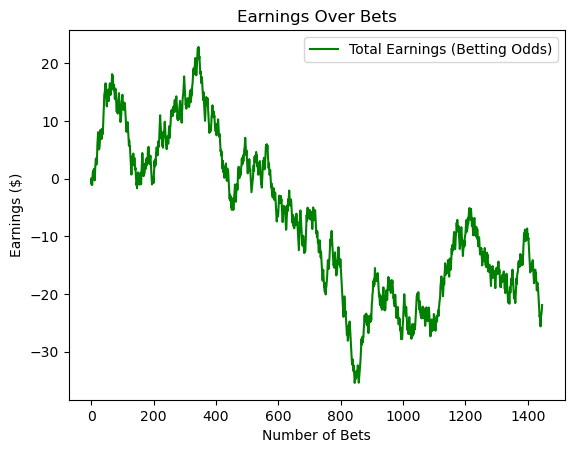

In [31]:
initial_dollar=1
predicted_bo = np.argmin(np.array(betting_data), axis=1)
bo_earnings = []

# Iterate through each data point for betting odds
for i in range(len(bo_labels)):
    if predicted_bo[i] == bo_labels[i]:
        bo_earnings.append(initial_dollar * (betting_data.at[i,predicted_bo[i]] - 1))
    else:
        bo_earnings.append(-initial_dollar)  # If the prediction is incorrect, earn nothing
total_bo_earnings = np.sum(bo_earnings)+initial_dollar
plt.plot(np.cumsum(bo_earnings) + initial_dollar, label='Total Earnings (Betting Odds)', color='green')
plt.xlabel('Number of Bets')
plt.ylabel('Earnings ($)')
plt.title('Earnings Over Bets')
plt.legend()
plt.show()

In [32]:
normalized_probas

array([[0.39616613, 0.30670927, 0.2971246 ],
       [0.20385051, 0.25821065, 0.53793884],
       [0.49628844, 0.26193001, 0.24178155],
       ...,
       [0.11190148, 0.17293866, 0.71515986],
       [0.58989141, 0.23743129, 0.1726773 ],
       [0.51167513, 0.26294416, 0.22538071]])

In [33]:
betting_odds_auc = roc_auc_score(bo_labels, normalized_probas, multi_class='ovr')
print(f"betting odds AUC: {betting_odds_auc}")

betting odds AUC: 0.657364594530662


In [34]:
normalized_probas = np.array(normalized_probas)

In [35]:
normalized_probas

array([[0.39616613, 0.30670927, 0.2971246 ],
       [0.20385051, 0.25821065, 0.53793884],
       [0.49628844, 0.26193001, 0.24178155],
       ...,
       [0.11190148, 0.17293866, 0.71515986],
       [0.58989141, 0.23743129, 0.1726773 ],
       [0.51167513, 0.26294416, 0.22538071]])

In [36]:
bo_classes = np.argmax(normalized_probas, axis=1)

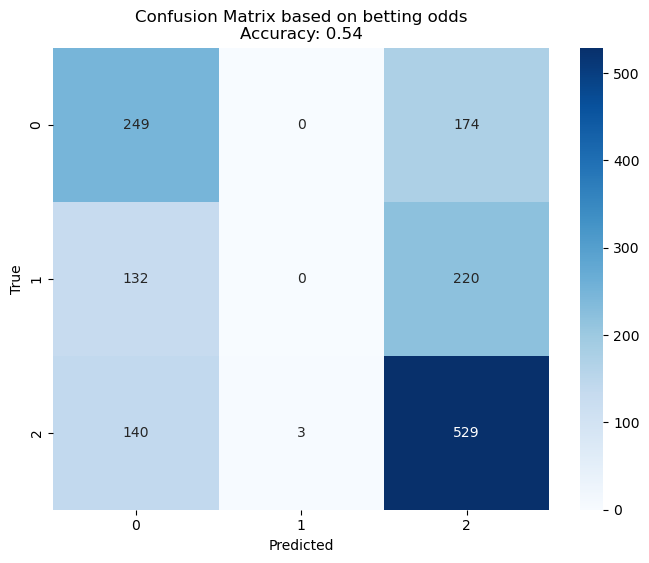

In [37]:
# Create a confusion matrix

conf_matrix = confusion_matrix(bo_labels, bo_classes)

# Calculate accuracy
accuracy = accuracy_score(bo_labels, bo_classes)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix based on betting odds\nAccuracy: {accuracy:.2f}')
plt.show()



Different way to model:
We can model the expected GD, and using that, we take the another model (svm or knn) to predict the outcome

In [38]:
X_train = train.copy()
X_test = test.copy()
# X_train.drop([ 'away_Points_form_pw',
#                  'home_points_to_championship',
#                 'home_points_to_ucl','home_points_to_rel','away_points_to_championship',
#              
#               'HomePlayer_Overall_mean_ln', 'AwayPlayer_Overall_mean_ln',
#               'Home_min_max','Away_min_max', 'capacity',
#               'AwayPlayer_Overall_min', 'HomePlayer_Overall_min'], inplace=True, axis=1)
# X_test.drop([ 'away_Points_form_pw',
#                  'home_points_to_championship',
#                 'home_points_to_ucl','home_points_to_rel','away_points_to_championship',
#                 'away_points_to_ucl',
#              'HomePlayer_Overall_mean_ln', 'AwayPlayer_Overall_mean_ln',  'Home_min_max','Away_min_max',
#               'AwayPlayer_Overall_min', 'HomePlayer_Overall_min','capacity',
#               ],inplace=True, axis=1)


In [39]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(X_train)
X_train = pd.DataFrame(train_scaled, columns=X_train.columns)

test_scaled = scaler.transform(X_test)
X_test = pd.DataFrame(test_scaled, columns=X_train.columns)




In [40]:
print('home scoring avg:', ytrain_home.mean(),'\nwith an sd of:', ytrain_home.std())
print('away scoring avg:', ytrain_away.mean(),'\nwith an sd of:', ytrain_away.std())

home scoring avg: 1.5481359743966785 
with an sd of: 1.31393457866488
away scoring avg: 1.23164086151717 
with an sd of: 1.1812280928511136


In [41]:
from sklearn.ensemble import RandomForestRegressor

home_reg = GridSearchCV(RandomForestRegressor(n_estimators=200),
                        param_grid= {'criterion': ['poisson'], 'max_depth': [5], 'max_features': [0.02, 0.07, .15, .25, 0.3], 'max_samples': [0.5]},
                        scoring='neg_mean_squared_error', cv=3, verbose=3)

away_reg =GridSearchCV(RandomForestRegressor(n_estimators=200),
                        param_grid={'criterion': ['poisson'], 'max_depth': [5], 'max_features': [0.02, 0.07, .15,.25, 0.3], 'max_samples': [0.25]},
                        scoring='neg_mean_squared_error', cv=3, verbose=3)


home_reg.fit(train, ytrain_home)
away_reg.fit(train, ytrain_away)
'''
best hyper parameters for home regression: {'criterion': 'poisson', 'max_depth': 5, 'max_features': 0.3, 'max_samples': 0.5}
best parameters for away reg: {'criterion': 'poisson', 'max_depth': 5, 'max_features': 0.3, 'max_samples': 0.25}
'''

print("best hyper parameters for home regression:", home_reg.best_params_)
print("best parameters for away reg:", away_reg.best_params_)
home_train = home_reg.predict(train)
away_train = away_reg.predict(train)

home_test = home_reg.predict(test)
away_test = away_reg.predict(test)
print('train home rmse:', np.sqrt(mean_squared_error(ytrain_home, home_train)))
print('train away rmse:', np.sqrt(mean_squared_error(ytrain_away, away_train)))

print('test home rmse:', np.sqrt(mean_squared_error(ytest_home, home_test)))
print('test away rmse:', np.sqrt(mean_squared_error(ytest_away, away_test)))


Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV 1/3] END criterion=poisson, max_depth=5, max_features=0.02, max_samples=0.5;, score=-1.593 total time=   0.4s
[CV 2/3] END criterion=poisson, max_depth=5, max_features=0.02, max_samples=0.5;, score=-1.505 total time=   0.3s
[CV 3/3] END criterion=poisson, max_depth=5, max_features=0.02, max_samples=0.5;, score=-1.531 total time=   0.3s
[CV 1/3] END criterion=poisson, max_depth=5, max_features=0.07, max_samples=0.5;, score=-1.502 total time=   0.7s
[CV 2/3] END criterion=poisson, max_depth=5, max_features=0.07, max_samples=0.5;, score=-1.460 total time=   0.7s
[CV 3/3] END criterion=poisson, max_depth=5, max_features=0.07, max_samples=0.5;, score=-1.465 total time=   0.7s
[CV 1/3] END criterion=poisson, max_depth=5, max_features=0.15, max_samples=0.5;, score=-1.481 total time=   1.3s
[CV 2/3] END criterion=poisson, max_depth=5, max_features=0.15, max_samples=0.5;, score=-1.453 total time=   1.3s
[CV 3/3] END criterion=poiss

In [42]:
def plot_by_matchweek(actual, output, weeks, title=''):
    df = pd.DataFrame({
        'Matchweek' : weeks.values,
        'output' : output,
        'actual' : actual
    })
    df['se'] = (actual -output) ** 2
    mse_by_week = df.groupby('Matchweek')['se'].mean()
    # Plot the MSE by matchweek
    plt.figure(figsize=(10, 6))
    plt.plot(mse_by_week.index, mse_by_week.values, marker='o')
    plt.title(title)
    plt.xlabel('Matchweek')
    plt.ylabel('Mean Squared Error')
    plt.grid(True)
    plt.show()


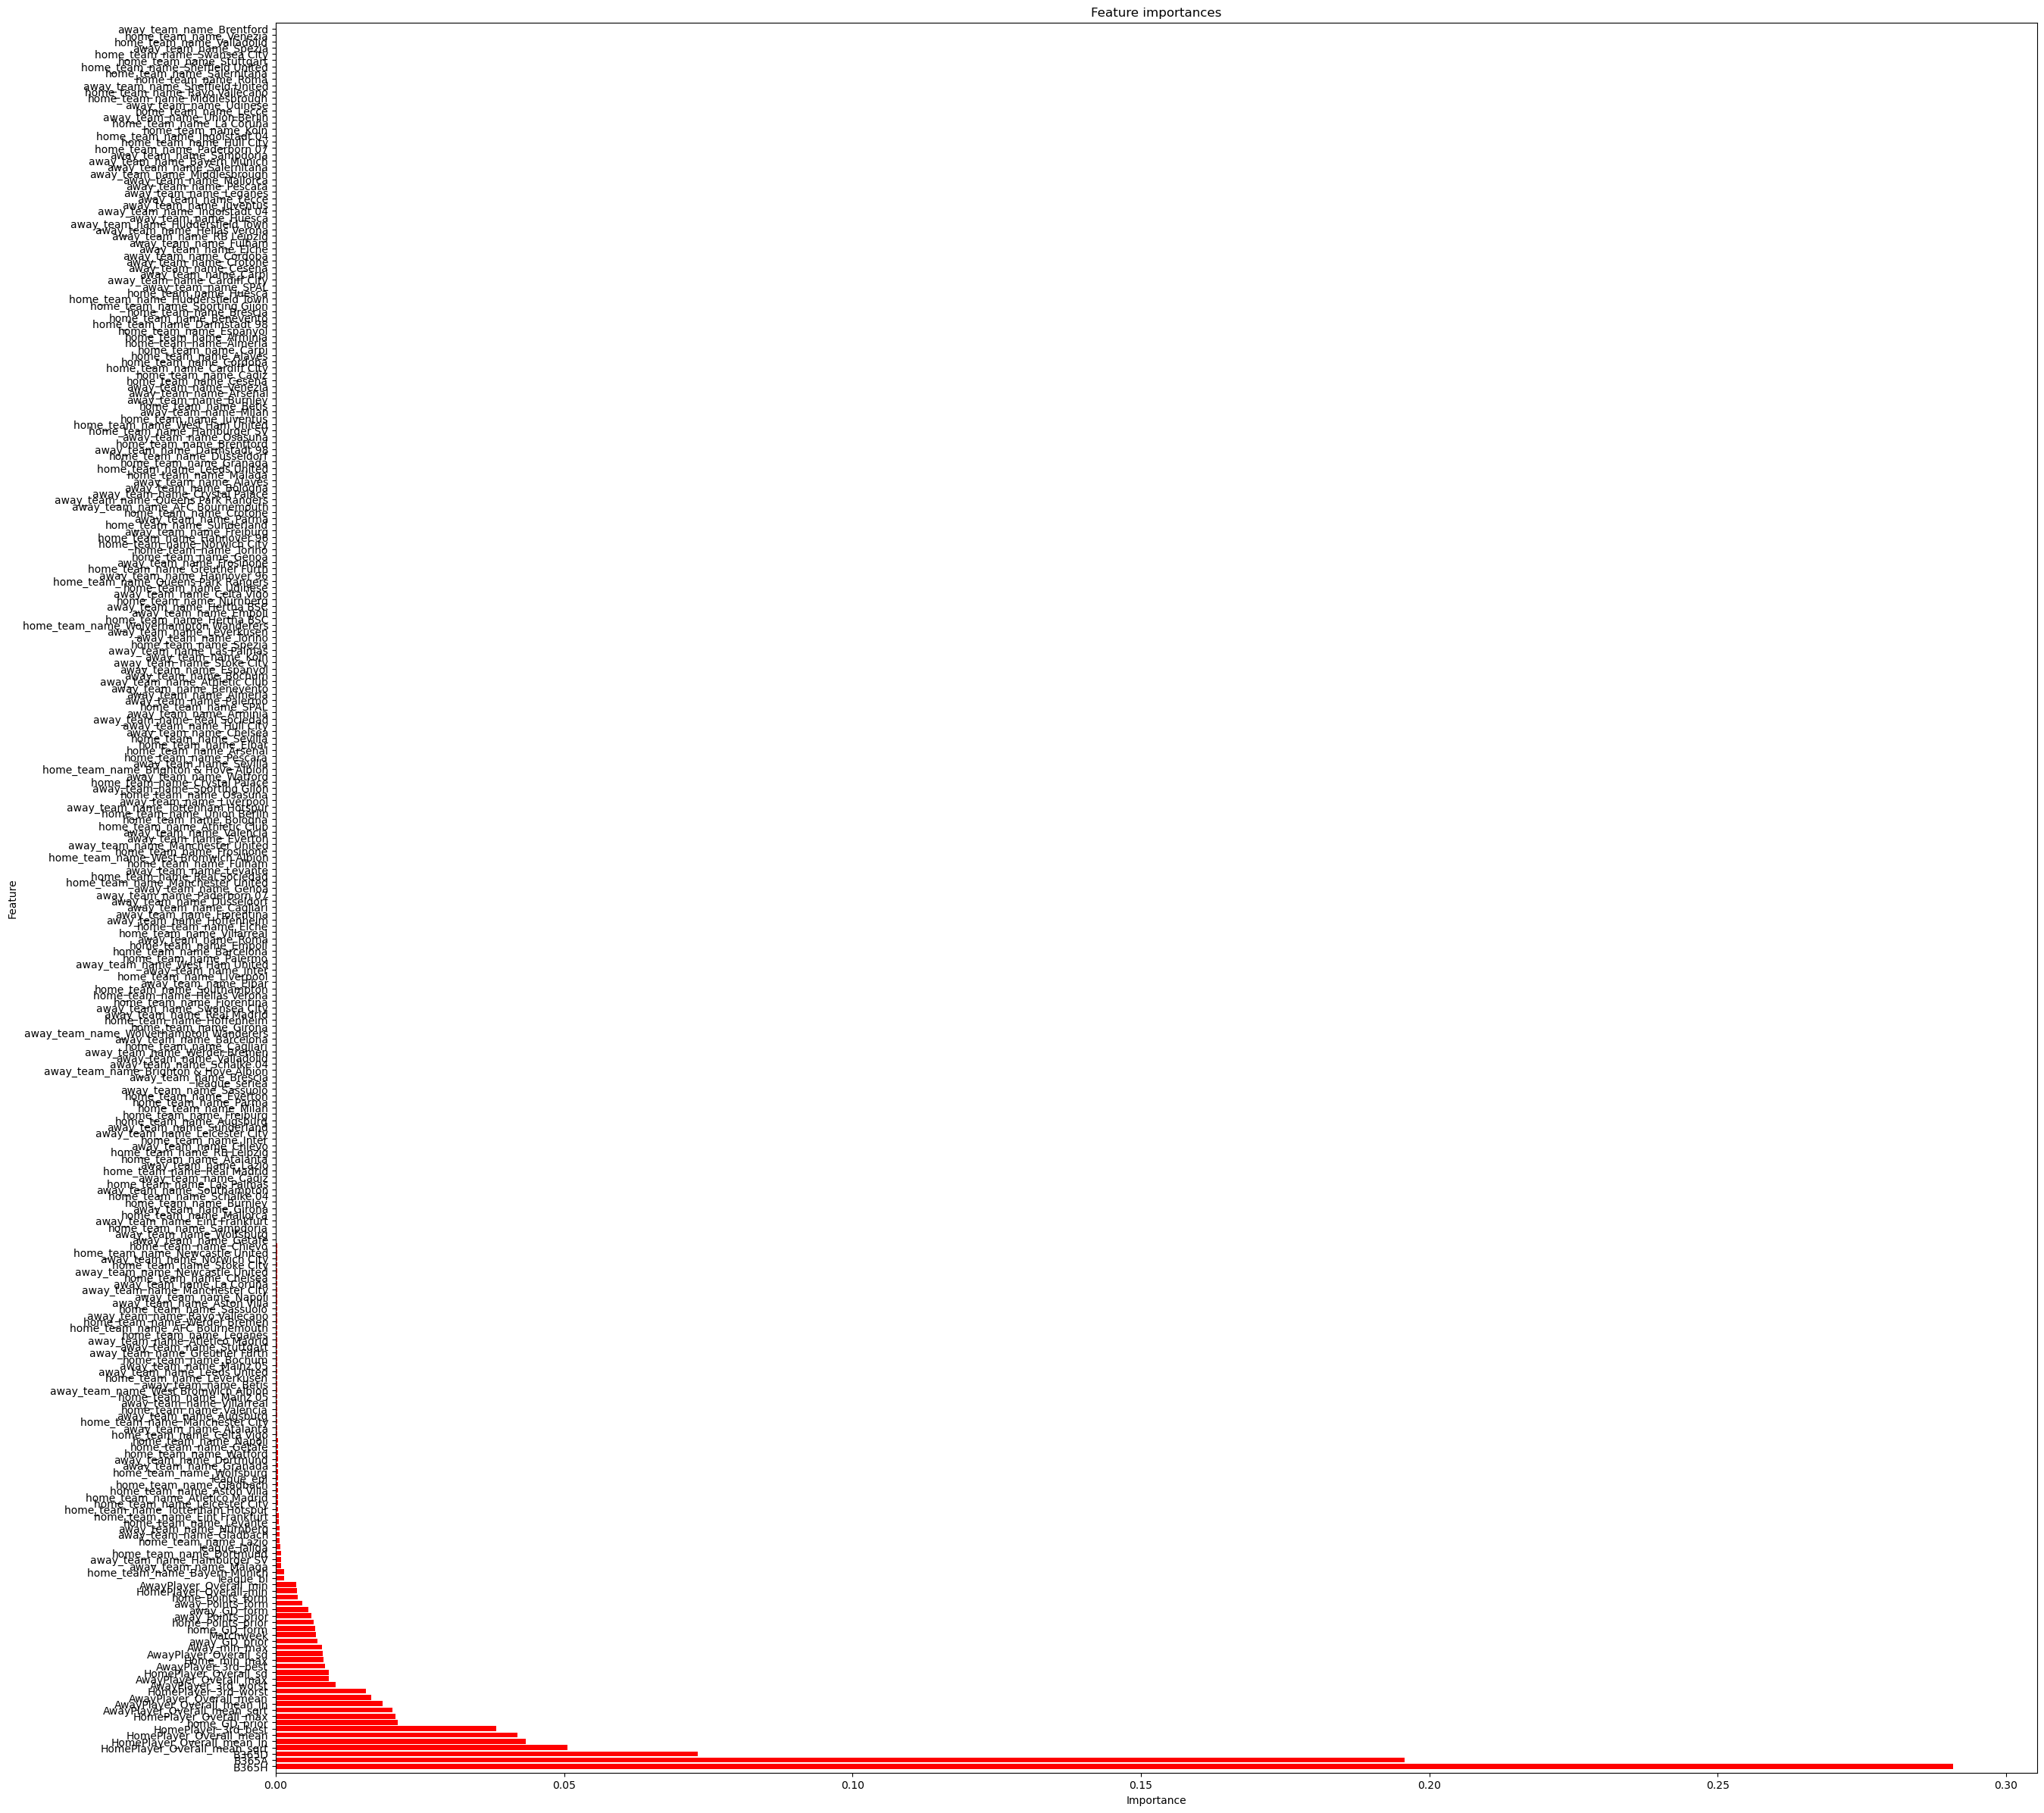

best hyper parameters for home regression: {'criterion': 'poisson', 'max_depth': 5, 'max_features': 0.3, 'max_samples': 0.5}
best parameters for away reg: {'criterion': 'poisson', 'max_depth': 5, 'max_features': 0.3, 'max_samples': 0.25}


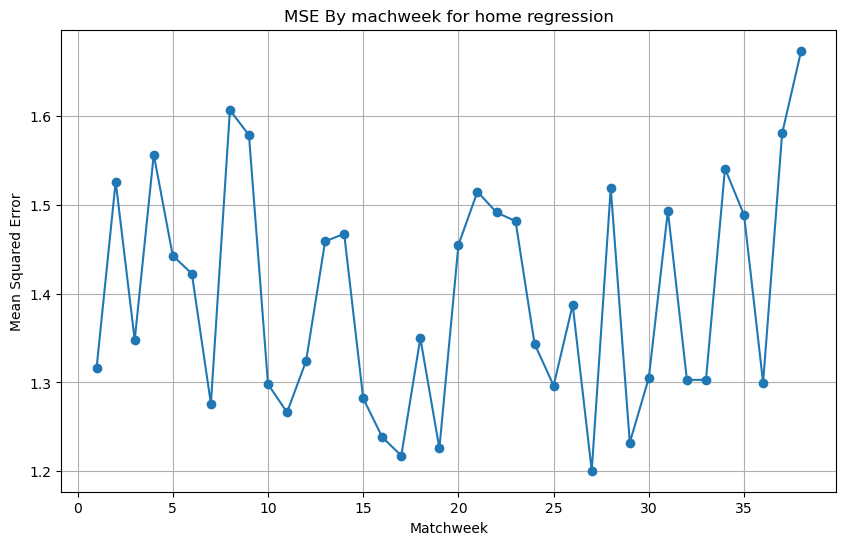

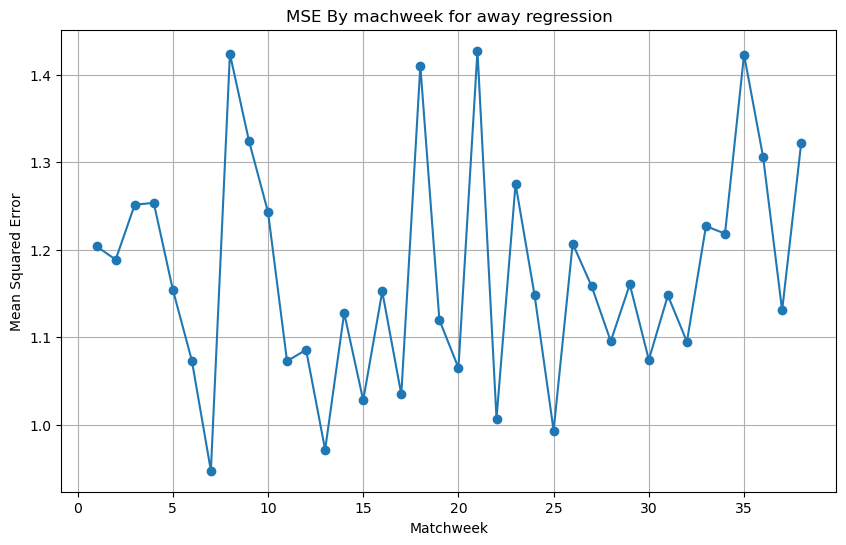

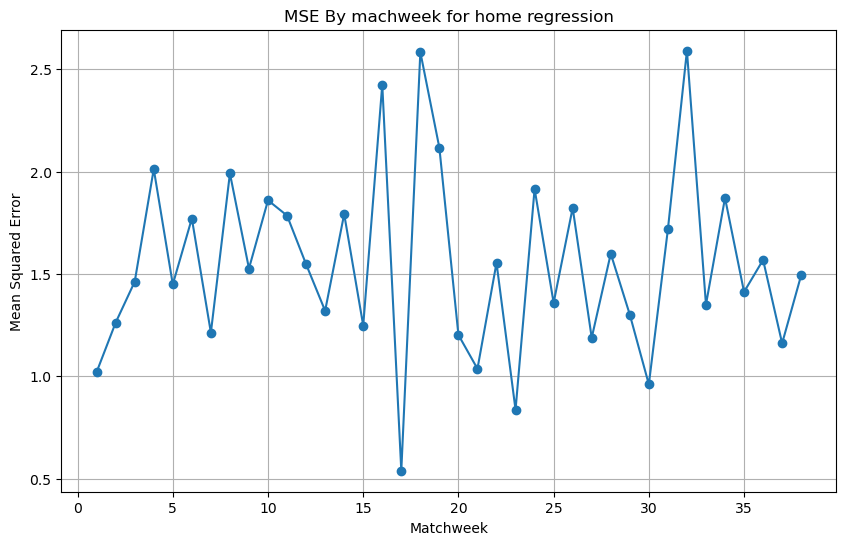

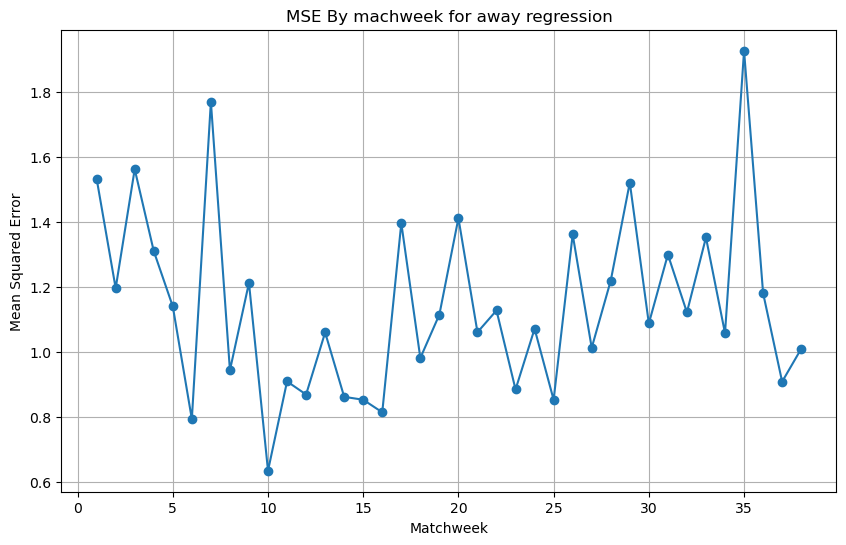

train home rmse: 1.181296057863775
train away rmse: 1.0813033823919889
test home rmse: 1.2451077040321508
test away rmse: 1.0665016593991987
(1447, 3)
for Test season, going via accuracy strategy, we earn:  -30.160000000000025
for Test season going by max returns strategy, we earn:  -6.930000000000004
for Test season, going with ln risk aversion strategy, we earn:  1.9300000000000104
for Test season, going with sqrt risk aversion strategy, we earn:  -29.690000000000047
for Test season, going with sqrt risk aversion of profits strategy, we earn:  65.83999999999989
for Test season, going via accuracy (tie odds added to winning odds) strategy, we earn:  -25.48000000000004
for Test season, going via max returns (tie odds added to winning odds) strategy, we earn:  14.309999999999992
for Test season, going for rev^proba of bet365 strategy, we earn:  -103.29000000000013
for Test season, going via sharpe ratio strategy, we earn:  -98.36000000000001


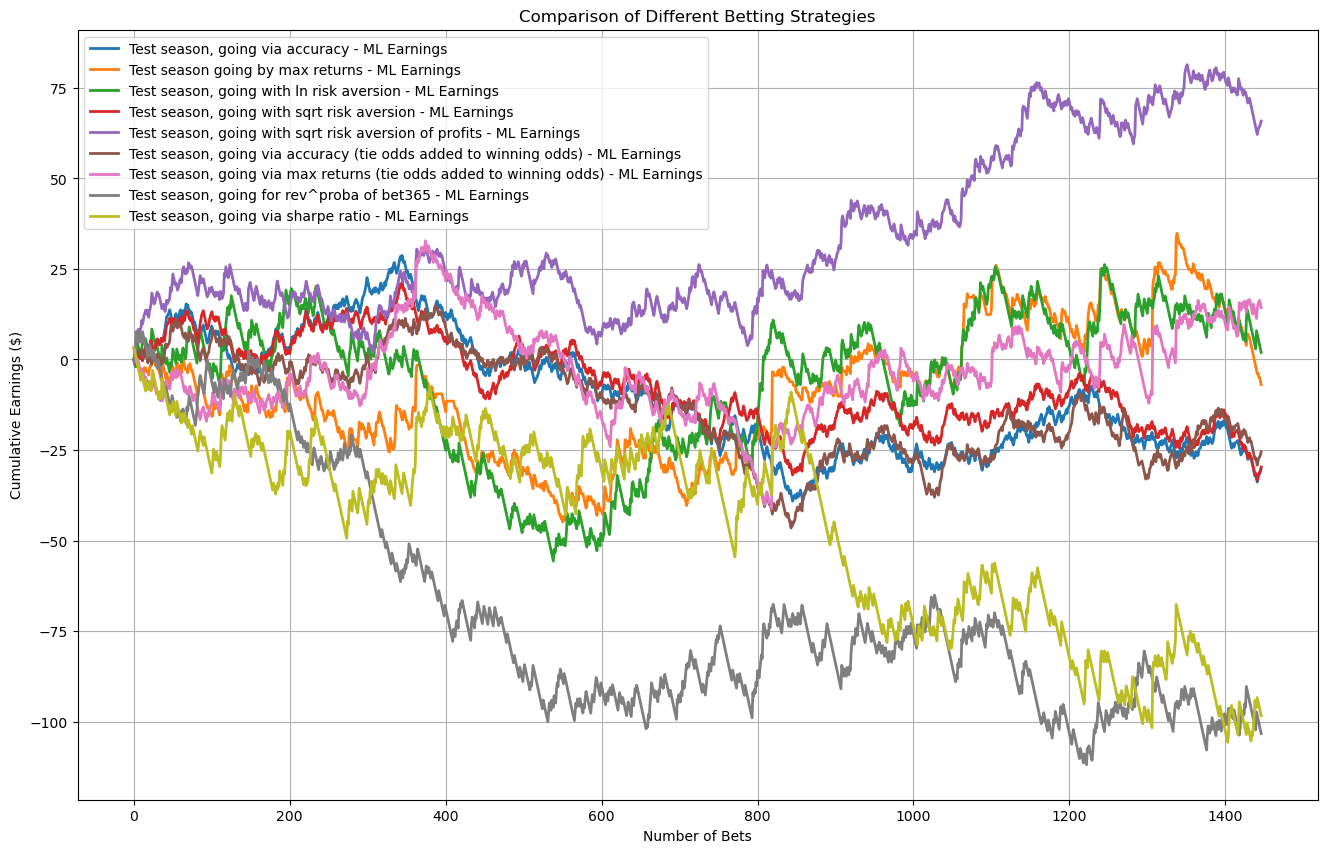

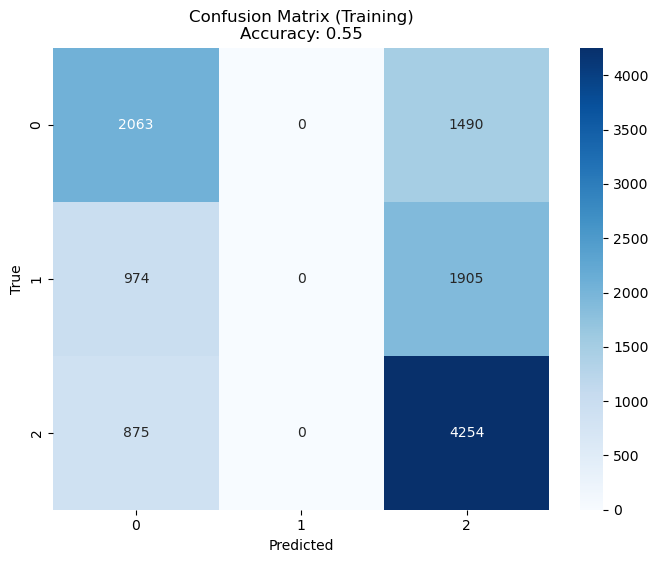

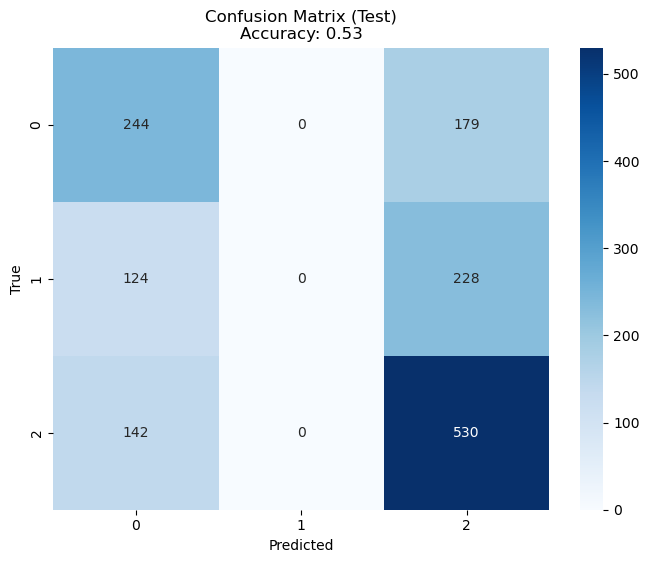

Training OvR AUC: 0.6954668754119844
Test OvR AUC: 0.6631134347199318


C:\Users\Yuval\AppData\Local\Temp\ipykernel_97844\1398689041.py:154: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train_mismatch_gaps, shade=True, color='blue', label='Mismatched')
C:\Users\Yuval\AppData\Local\Temp\ipykernel_97844\1398689041.py:155: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train_match_gaps, shade=True, color='green', label='Matched')
C:\Users\Yuval\AppData\Local\Temp\ipykernel_97844\1398689041.py:162: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(test_mismatch_gaps, shade=True, color='red', label='Mismatched')
C:\Users\Yuval\AppData\Local\Temp\ipykernel_97844\1398689041.py:163: FutureWarning: 

`sh

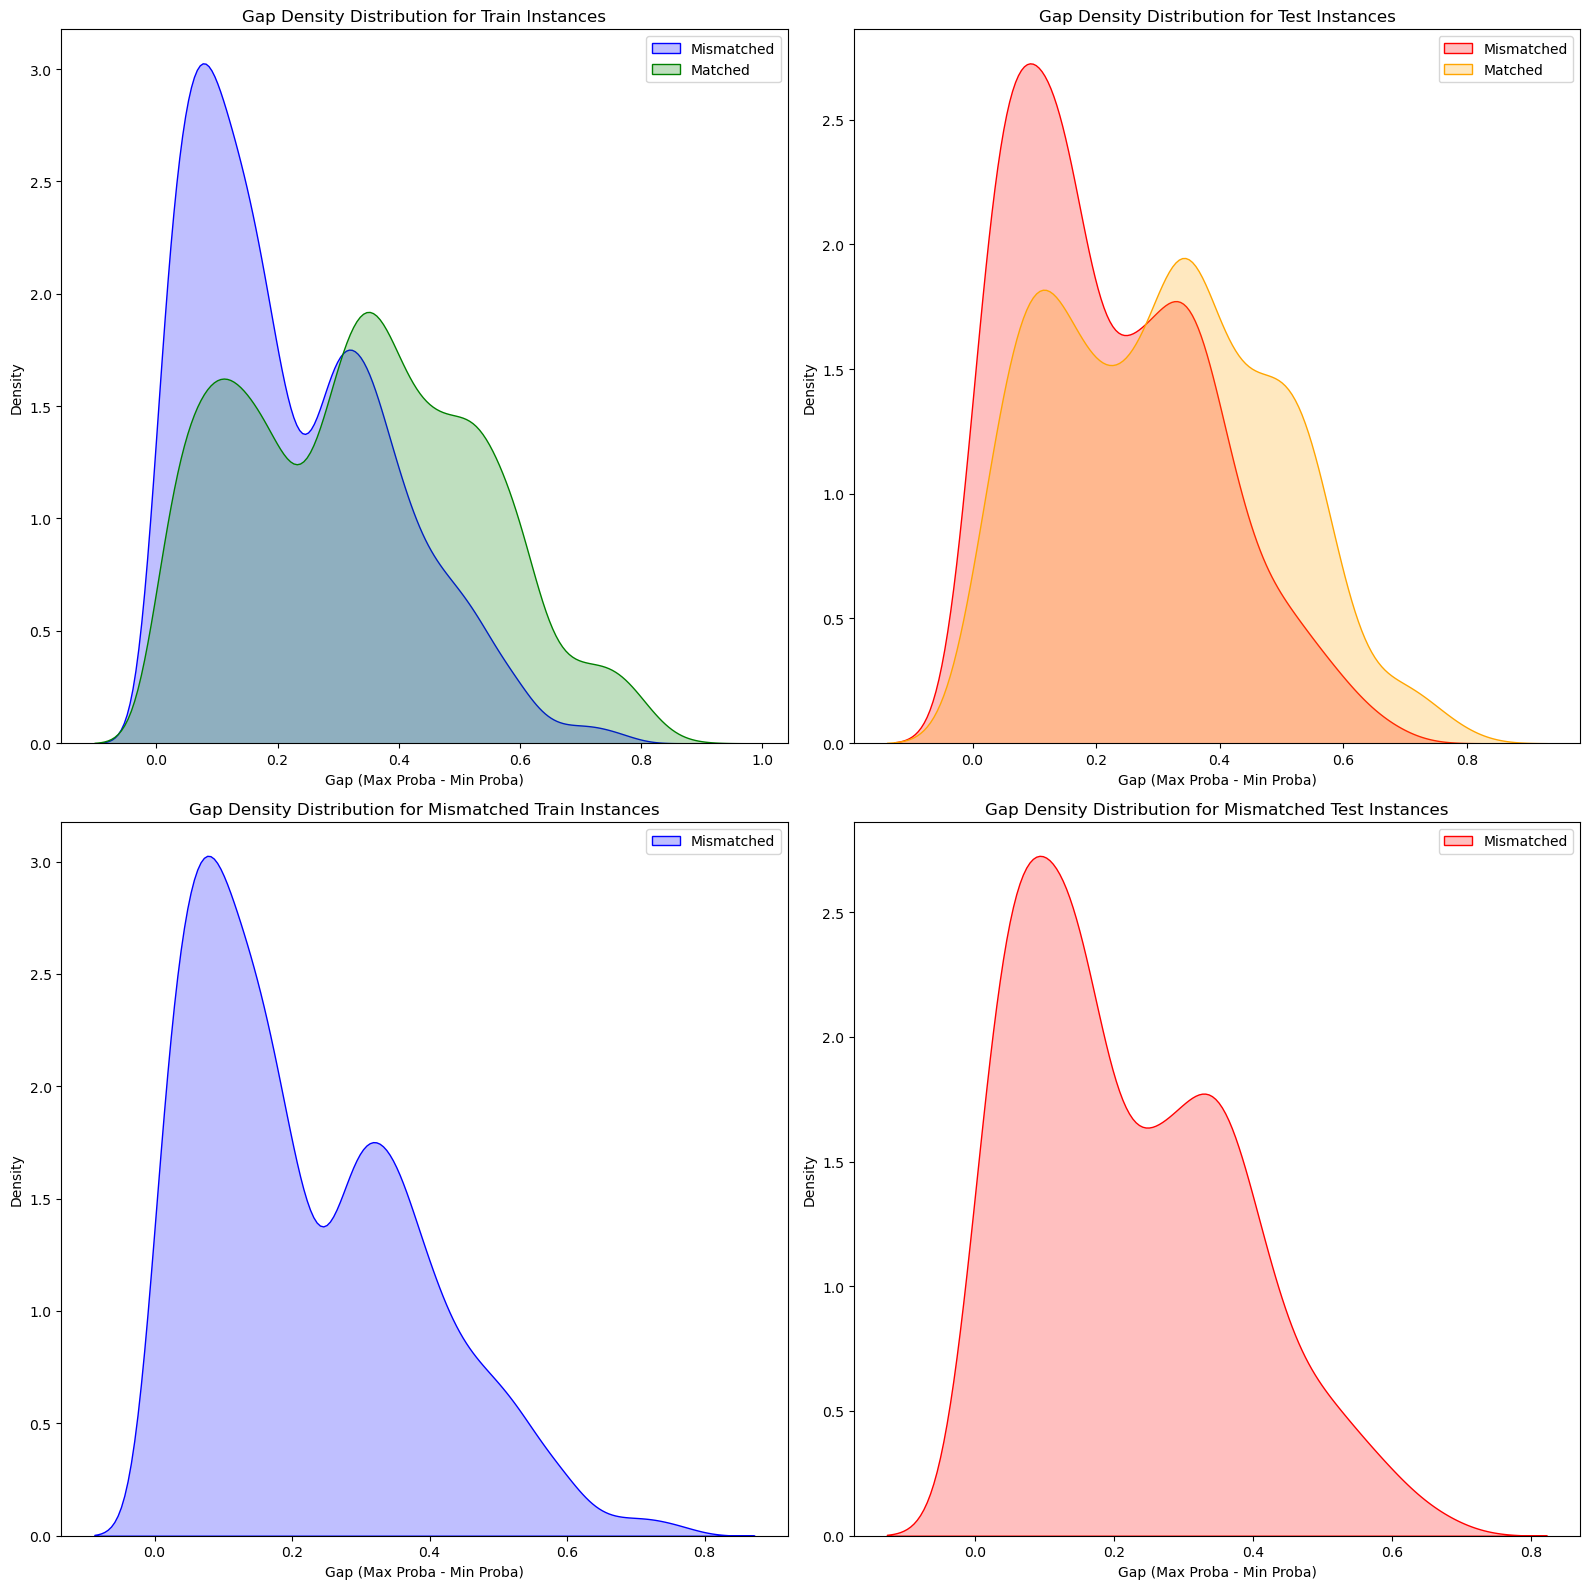

"\nbest hyper parameters for home regression: {'criterion': 'poisson', 'max_depth': 5, 'max_features': 0.3333333333333333, 'max_samples': 0.15}\nbest parameters for away reg: {'criterion': 'poisson', 'max_depth': 5, 'max_features': 0.3333333333333333, 'max_samples': 0.2}\n"

In [43]:

# Get feature importances
importances = home_reg.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = train.columns[indices]

# Plot the feature importances
plt.figure(figsize=(30,30))
plt.title("Feature importances")
plt.barh(range(train.shape[1]), importances[indices], color="r", align="center")
plt.yticks(range(train.shape[1]), feature_names)
plt.ylim([-1, train.shape[1]])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

print("best hyper parameters for home regression:", home_reg.best_params_)
print("best parameters for away reg:", away_reg.best_params_)

home_train = home_reg.predict(train)
away_train = away_reg.predict(train)

plot_by_matchweek(ytrain_home, home_train, train['Matchweek'], 'MSE By machweek for home regression')
plot_by_matchweek(ytrain_away, away_train, train['Matchweek'], 'MSE By machweek for away regression')

home_test = home_reg.predict(test)
away_test = away_reg.predict(test)

plot_by_matchweek(ytest_home, home_test, test['Matchweek'], 'MSE By machweek for home regression')
plot_by_matchweek(ytest_away, away_test, test['Matchweek'], 'MSE By machweek for away regression')

print('train home rmse:', np.sqrt(mean_squared_error(ytrain_home, home_train)))
print('train away rmse:', np.sqrt(mean_squared_error(ytrain_away, away_train)))

print('test home rmse:', np.sqrt(mean_squared_error(ytest_home, home_test)))
print('test away rmse:', np.sqrt(mean_squared_error(ytest_away, away_test)))

train_probas = extract_poisson_probas(home_train, away_train)
test_probas = extract_poisson_probas(home_test, away_test)

sharpe_ratios = np.asarray(test_probas*(betting_data**2 - test_probas*(betting_data**2) + 2*test_probas*betting_data - 1))
print(sharpe_ratios.shape)
# bet_and_plot_thresh(test_probas, y_test, betting_data, normalized_probas, extra_title=' Test season, going via accuracy')
# bet_and_plot_thresh(np.asarray(betting_data)*test_probas, y_test, betting_data, normalized_probas, extra_title=' Test season going by max returns', threshold =1)
# bet_and_plot_thresh(test_probas*np.log(np.asarray(betting_data)), y_test, betting_data, normalized_probas, extra_title=' Test season, going with ln risk aversion', threshold=0)
# bet_and_plot_thresh(test_probas*np.sqrt(np.asarray(betting_data)), y_test, betting_data, normalized_probas, extra_title=' Test season, going with sqrt risk aversion', threshold=0)
# bet_and_plot_thresh(test_probas*np.sqrt(np.asarray(betting_data)-1), y_test, betting_data, normalized_probas, extra_title=' Test season, going with sqrt risk aversion', threshold=0)

# bet_and_plot_thresh(np.power(np.asarray(betting_data),normalized_probas), y_test, betting_data, normalized_probas, extra_title=' Test season, going for rev^proba of bet365', threshold=1)
# bet_and_plot_thresh(sharpe_ratios, y_test, betting_data, normalized_probas, extra_title=' Test season, going via sharpe ratio')

strategies = []

strategies.append(bet_thresh(test_probas, y_test, betting_data, normalized_probas, extra_title='Test season, going via accuracy'))
strategies.append(bet_thresh(np.asarray(betting_data)*test_probas, y_test, betting_data, normalized_probas, extra_title='Test season going by max returns', threshold=1))
strategies.append(bet_thresh(test_probas*np.log(np.asarray(betting_data)), y_test, betting_data, normalized_probas, extra_title='Test season, going with ln risk aversion', threshold=0))
strategies.append(bet_thresh(test_probas*np.sqrt(np.asarray(betting_data)), y_test, betting_data, normalized_probas, extra_title='Test season, going with sqrt risk aversion', threshold=0))
strategies.append(bet_thresh(test_probas*np.sqrt(np.asarray(betting_data)-1), y_test, betting_data, normalized_probas, extra_title='Test season, going with sqrt risk aversion of profits', threshold=0))
test_probas_tie = test_probas.copy()
test_probas_tie[:,2] += test_probas_tie[:,1]
test_probas_tie[:,1] = 0
strategies.append(bet_thresh(test_probas_tie, y_test, betting_data, normalized_probas, extra_title='Test season, going via accuracy (tie odds added to winning odds)'))
strategies.append(bet_thresh(np.asarray(betting_data)*test_probas_tie, y_test, betting_data, normalized_probas, extra_title='Test season, going via max returns (tie odds added to winning odds)'))

strategies.append(bet_thresh(np.power(np.asarray(betting_data),normalized_probas), y_test, betting_data, normalized_probas, extra_title='Test season, going for rev^proba of bet365', threshold=1))
strategies.append(bet_thresh(sharpe_ratios, y_test, betting_data, normalized_probas, extra_title='Test season, going via sharpe ratio'))
plt.figure(figsize=(16, 10))

for cum_earnings, cum_bo_earnings, cum_delta_earnings, title in strategies:
    print('for '+title+' strategy, we earn: ',cum_earnings[-1])
    plt.plot(cum_earnings, label=f'{title} - ML Earnings', linestyle='-', linewidth=2)
    #plt.plot(cum_bo_earnings, label=f'{title} - Betting Odds Earnings', linestyle='--', linewidth=2)
    #plt.plot(cum_delta_earnings, label=f'{title} - Delta Earnings', linestyle=':', linewidth=2)

plt.xlabel('Number of Bets')
plt.ylabel('Cumulative Earnings ($)')
plt.title('Comparison of Different Betting Strategies')
plt.legend(loc='best')
plt.grid(True)
plt.show()

train_classes = np.argmax(train_probas, axis=1)
train_classes = train_classes

# Create a confusion matrix
conf_matrix = confusion_matrix(y_train, train_classes)

# Calculate accuracy
accuracy = accuracy_score(y_train, train_classes)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (Training)\nAccuracy: {accuracy:.2f}')
plt.show()

test_classes = np.argmax(test_probas, axis=1)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, test_classes)

# Calculate accuracy
accuracy = accuracy_score(y_test, test_classes)


# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (Test)\nAccuracy: {accuracy:.2f}')
plt.show()
train_auc_ovr = roc_auc_score(y_train, train_probas, multi_class='ovr')
print(f"Training OvR AUC: {train_auc_ovr}")

# Calculate OvO AUC for the test set
test_auc_ovr = roc_auc_score(y_test, test_probas, multi_class='ovr')
print(f"Test OvR AUC: {test_auc_ovr}")

train_bets = np.asarray(train[['B365A','B365D', 'B365A']])
# Calculate the max and min probabilities
train_max_proba = np.max(train_probas, axis=1)
train_min_proba = np.sort(train_probas, axis=1)[:, ::-1][:,1]
test_max_proba = np.max(test_probas, axis=1)
test_min_proba = np.sort(test_probas, axis=1)[:, ::-1][:,1]

# Calculate the gaps
train_gaps = train_max_proba - train_min_proba
test_gaps = test_max_proba - test_min_proba

# Get predicted labels
train_preds = np.argmax(train_probas, axis=1)
test_preds = np.argmax(test_probas, axis=1)

# Identify mismatches
train_mismatches = train_preds != y_train
test_mismatches = test_preds != y_test

# Identify matches
train_matches = train_preds == y_train
test_matches = test_preds == y_test

# Filter gaps for mismatched and matched instances
train_mismatch_gaps = train_gaps[train_mismatches]
test_mismatch_gaps = test_gaps[test_mismatches]
train_match_gaps = train_gaps[train_matches]
test_match_gaps = test_gaps[test_matches]

# Plot the density distributions
plt.figure(figsize=(16, 16))

plt.subplot(2, 2, 1)
sns.kdeplot(train_mismatch_gaps, shade=True, color='blue', label='Mismatched')
sns.kdeplot(train_match_gaps, shade=True, color='green', label='Matched')
plt.xlabel('Gap (Max Proba - Min Proba)')
plt.ylabel('Density')
plt.title('Gap Density Distribution for Train Instances')
plt.legend()

plt.subplot(2, 2, 2)
sns.kdeplot(test_mismatch_gaps, shade=True, color='red', label='Mismatched')
sns.kdeplot(test_match_gaps, shade=True, color='orange', label='Matched')
plt.xlabel('Gap (Max Proba - Min Proba)')
plt.ylabel('Density')
plt.title('Gap Density Distribution for Test Instances')
plt.legend()

plt.subplot(2, 2, 3)
sns.kdeplot(train_mismatch_gaps, shade=True, color='blue', label='Mismatched')
plt.xlabel('Gap (Max Proba - Min Proba)')
plt.ylabel('Density')
plt.title('Gap Density Distribution for Mismatched Train Instances')
plt.legend()

plt.subplot(2, 2, 4)
sns.kdeplot(test_mismatch_gaps, shade=True, color='red', label='Mismatched')
plt.xlabel('Gap (Max Proba - Min Proba)')
plt.ylabel('Density')
plt.title('Gap Density Distribution for Mismatched Test Instances')
plt.legend()

plt.tight_layout()
plt.show()
'''
best hyper parameters for home regression: {'criterion': 'poisson', 'max_depth': 5, 'max_features': 0.3333333333333333, 'max_samples': 0.15}
best parameters for away reg: {'criterion': 'poisson', 'max_depth': 5, 'max_features': 0.3333333333333333, 'max_samples': 0.2}
'''

In [44]:
# # ## Save the model

with open('../models/legacy/RFHome.pkl', 'wb') as f:
    pickle.dump(home_reg.best_estimator_, f)

with open('../models/legacy/RFAway.pkl', 'wb') as f:
    pickle.dump(away_reg.best_estimator_, f)


In [45]:
from xgboost import XGBRegressor

home_reg = GridSearchCV(XGBRegressor(eval_metric ='poisson-nloglik'),
                        param_grid={'colsample_bytree': [0.5], 'max_depth': [1], 'n_estimators': [70], 'objective': ['count:poisson'], 'subsample': [1, .75, .5]},
                        scoring='neg_mean_squared_error', cv=3, verbose=3)

away_reg =GridSearchCV(XGBRegressor(eval_metric ='poisson-nloglik'),
                        param_grid={'colsample_bytree': [0.5], 'max_depth': [1], 'n_estimators': [130], 'objective': ['count:poisson'], 'subsample': [1, .75, .5]},
                        scoring='neg_mean_squared_error', cv=3, verbose=3)



home_reg.fit(train, ytrain_home)
away_reg.fit(train, ytrain_away)


print("best hyper parameters for home regression:", home_reg.best_params_)
print("best parameters for away reg:", away_reg.best_params_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV 1/3] END colsample_bytree=0.5, max_depth=1, n_estimators=70, objective=count:poisson, subsample=1;, score=-1.476 total time=   0.2s
[CV 2/3] END colsample_bytree=0.5, max_depth=1, n_estimators=70, objective=count:poisson, subsample=1;, score=-1.448 total time=   0.1s
[CV 3/3] END colsample_bytree=0.5, max_depth=1, n_estimators=70, objective=count:poisson, subsample=1;, score=-1.454 total time=   0.1s
[CV 1/3] END colsample_bytree=0.5, max_depth=1, n_estimators=70, objective=count:poisson, subsample=0.75;, score=-1.479 total time=   0.3s
[CV 2/3] END colsample_bytree=0.5, max_depth=1, n_estimators=70, objective=count:poisson, subsample=0.75;, score=-1.448 total time=   0.1s
[CV 3/3] END colsample_bytree=0.5, max_depth=1, n_estimators=70, objective=count:poisson, subsample=0.75;, score=-1.456 total time=   0.2s
[CV 1/3] END colsample_bytree=0.5, max_depth=1, n_estimators=70, objective=count:poisson, subsample=0.5;, score=-1.4

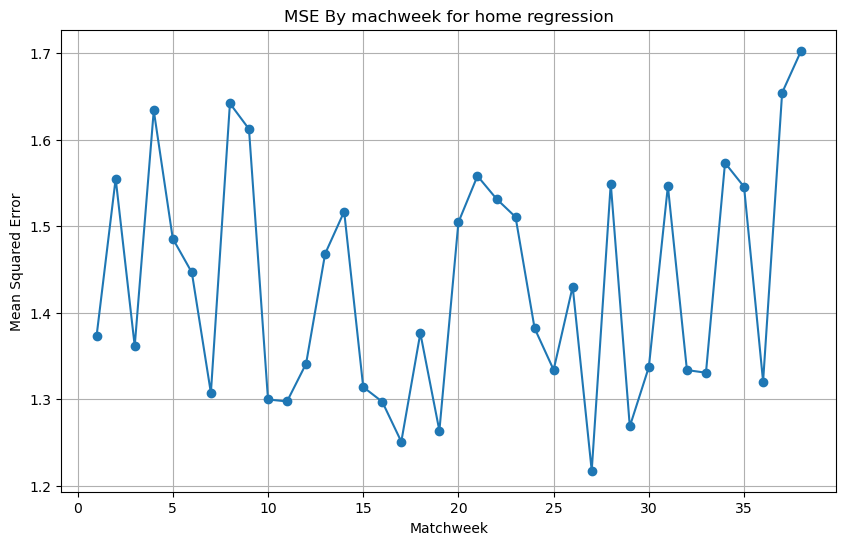

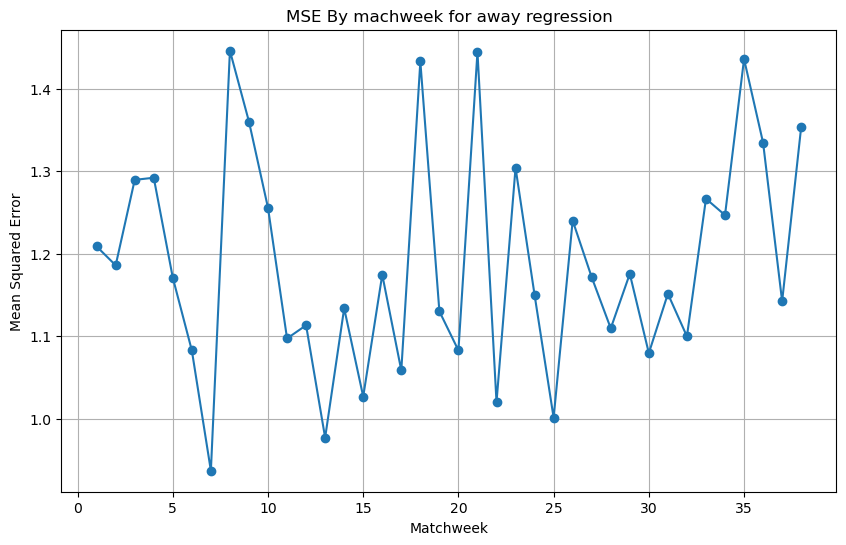

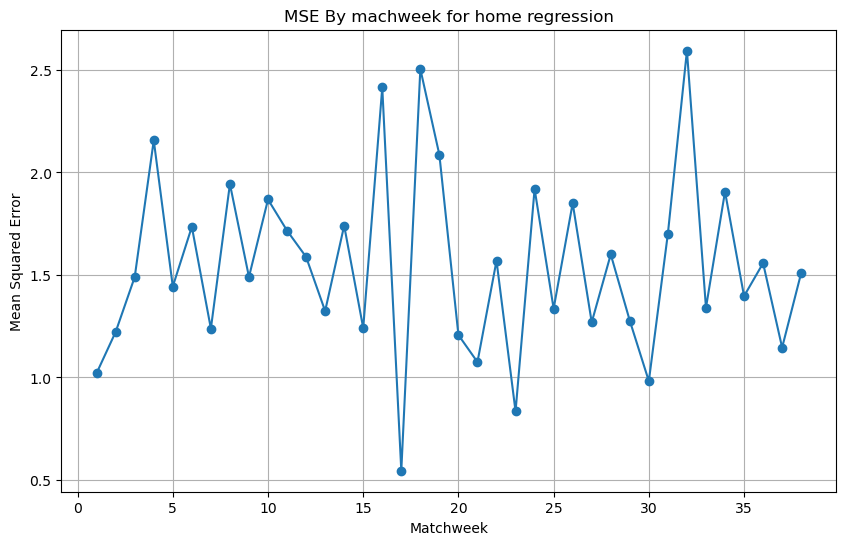

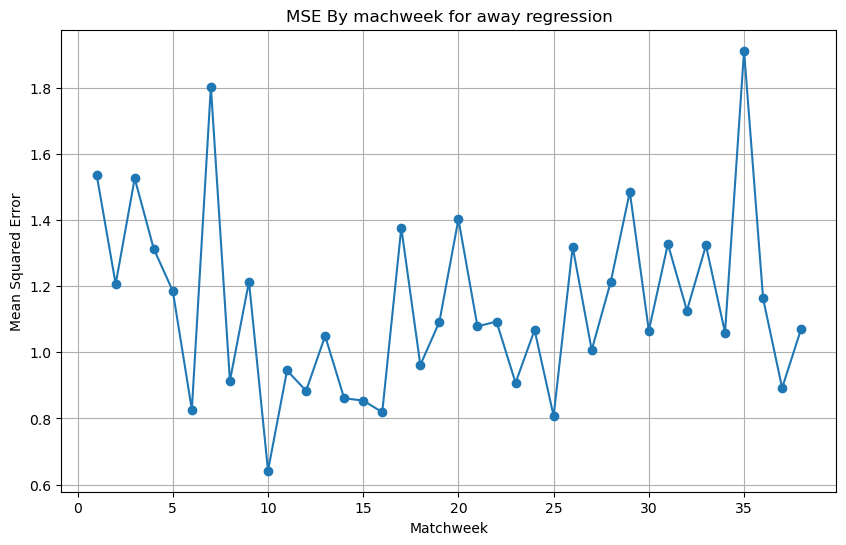

train home rmse: 1.1963073972786937
train away rmse: 1.0889163331112603
test home rmse: 1.2449044966620753
test away rmse: 1.0649340018244327
(1447, 3)
for Test season, going via accuracy strategy, we earn:  -29.640000000000015
for Test season going by max returns strategy, we earn:  17.72000000000003
for Test season, going with ln risk aversion strategy, we earn:  11.300000000000013
for Test season, going with sqrt risk aversion strategy, we earn:  -21.529999999999987
for Test season, going with sqrt risk aversion of profits strategy, we earn:  -20.510000000000012
for Test season, going via accuracy (tie odds added to winning odds) strategy, we earn:  -22.250000000000007
for Test season, going via max returns (tie odds added to winning odds) strategy, we earn:  17.690000000000005
for Test season, going for rev^proba of bet365 strategy, we earn:  -103.29000000000013
for Test season, going via sharpe ratio strategy, we earn:  -68.49999999999999


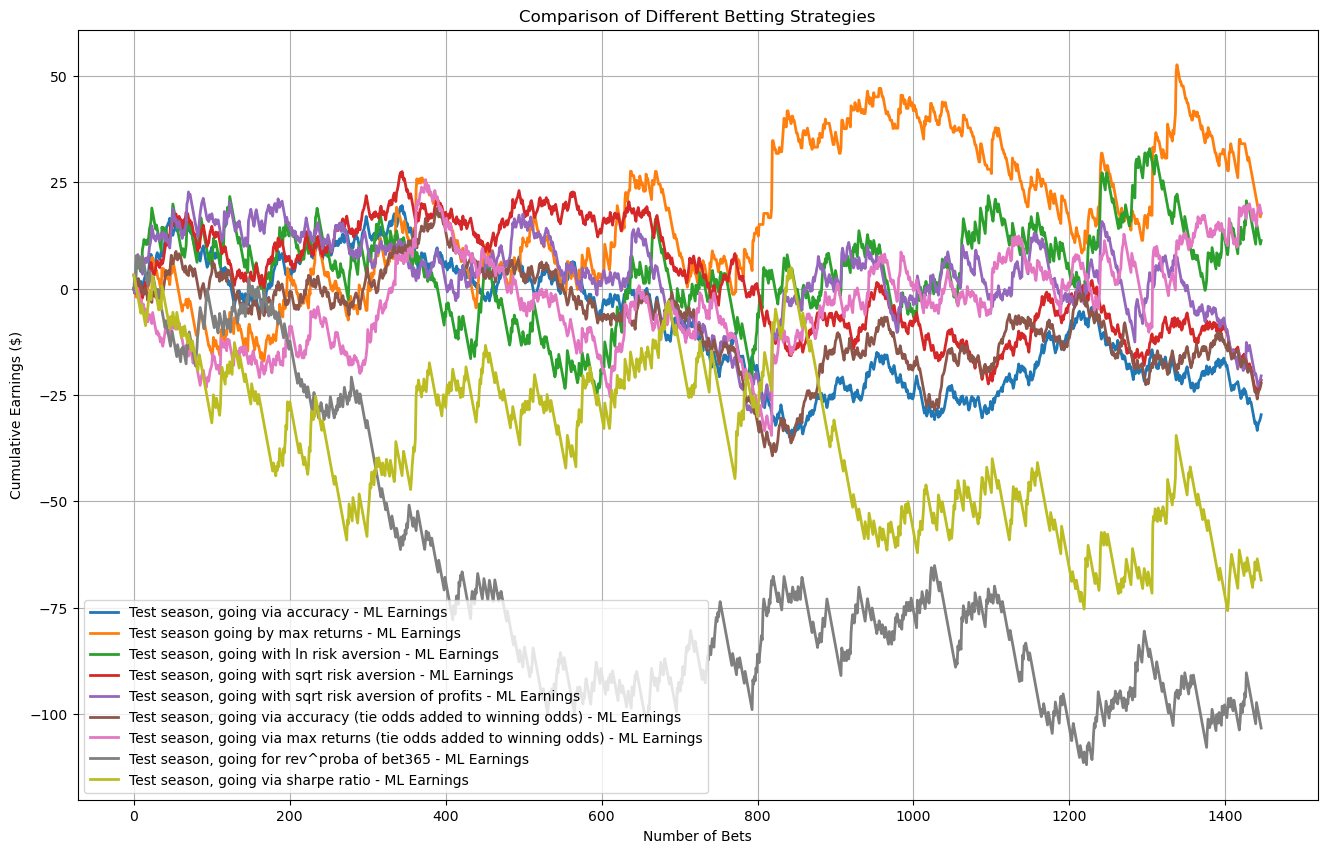

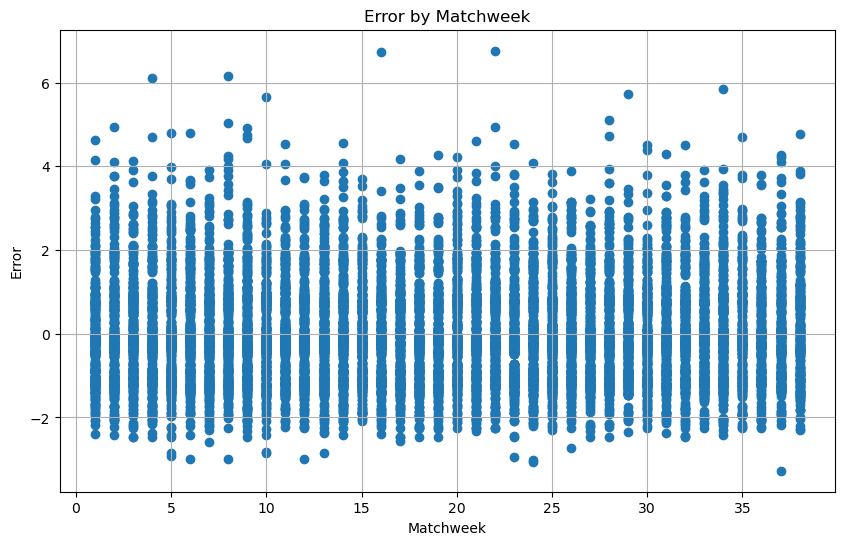

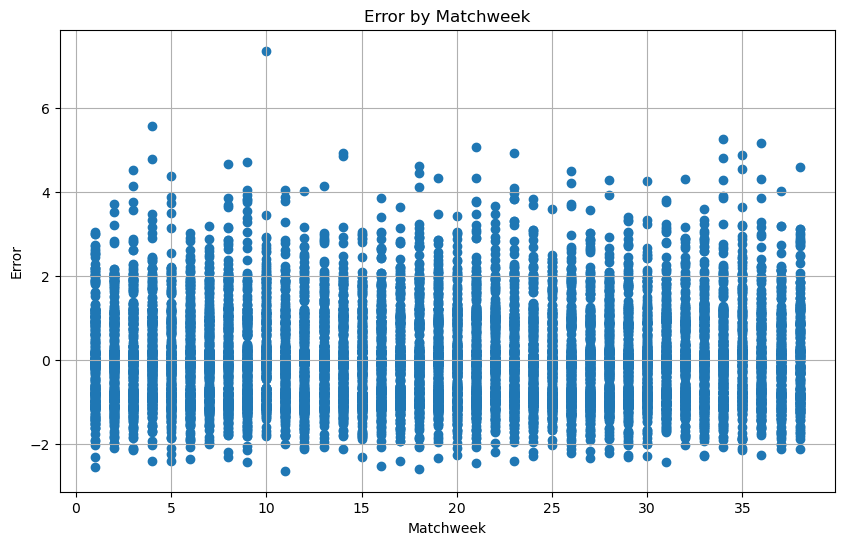

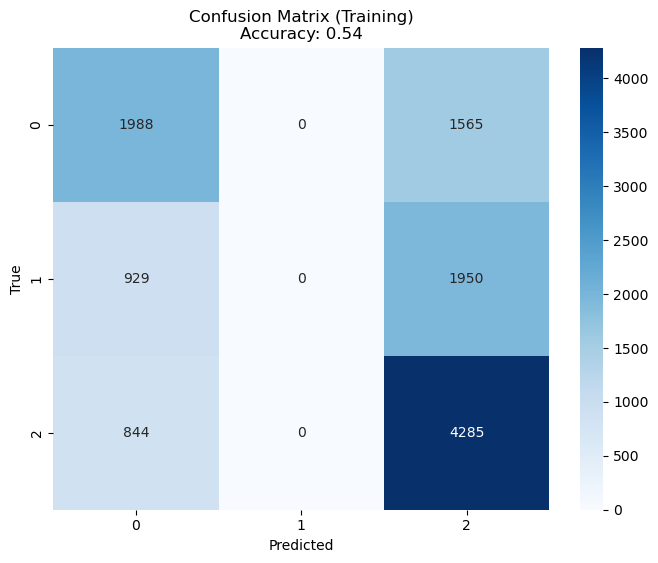

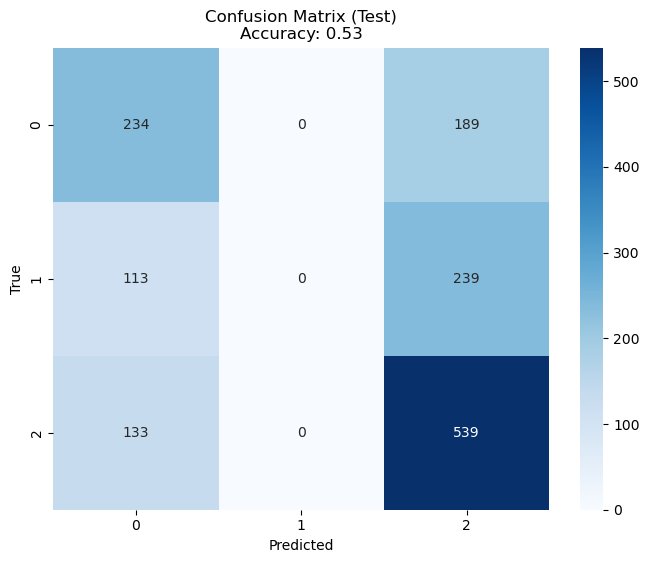

Training OvR AUC: 0.6896848399000457
Test OvR AUC: 0.6628750884508708


C:\Users\Yuval\AppData\Local\Temp\ipykernel_97844\1463878670.py:159: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train_mismatch_gaps, shade=True, color='blue', label='Mismatched')
C:\Users\Yuval\AppData\Local\Temp\ipykernel_97844\1463878670.py:160: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train_match_gaps, shade=True, color='green', label='Matched')
C:\Users\Yuval\AppData\Local\Temp\ipykernel_97844\1463878670.py:167: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(test_mismatch_gaps, shade=True, color='red', label='Mismatched')
C:\Users\Yuval\AppData\Local\Temp\ipykernel_97844\1463878670.py:168: FutureWarning: 

`sh

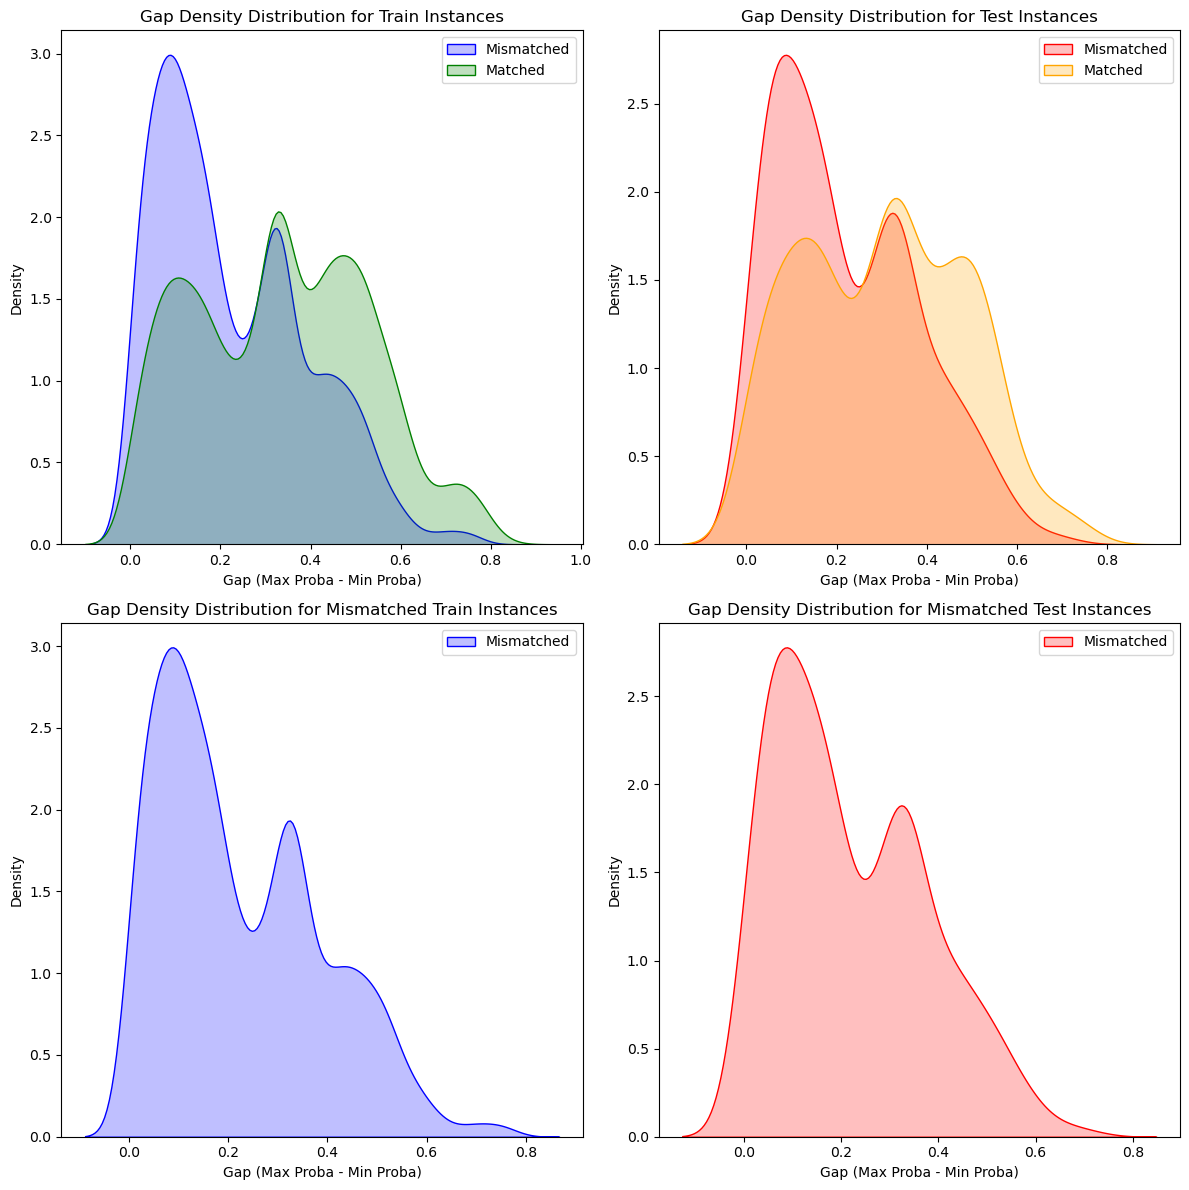

"\nbest hyper parameters for home regression: {'max_depth': 1, 'n_estimators': 100, 'objective': 'count:poisson', 'subsample': 0.5}\nbest parameters for away reg: {'max_depth': 1, 'n_estimators': 50, 'objective': 'count:poisson', 'subsample': 0.5}\n"

In [46]:

home_train = home_reg.predict(train)
away_train = away_reg.predict(train)

plot_by_matchweek(ytrain_home, home_train, train['Matchweek'], 'MSE By machweek for home regression')
plot_by_matchweek(ytrain_away, away_train, train['Matchweek'], 'MSE By machweek for away regression')

home_test = home_reg.predict(test)
away_test = away_reg.predict(test)

plot_by_matchweek(ytest_home, home_test, test['Matchweek'], 'MSE By machweek for home regression')
plot_by_matchweek(ytest_away, away_test, test['Matchweek'], 'MSE By machweek for away regression')
print('train home rmse:', np.sqrt(mean_squared_error(ytrain_home, home_train)))
print('train away rmse:', np.sqrt(mean_squared_error(ytrain_away, away_train)))

print('test home rmse:', np.sqrt(mean_squared_error(ytest_home, home_test)))
print('test away rmse:', np.sqrt(mean_squared_error(ytest_away, away_test)))

train_probas = extract_poisson_probas(home_train, away_train)
test_probas = extract_poisson_probas(home_test, away_test)

sharpe_ratios = np.asarray(test_probas*(betting_data**2 - test_probas*(betting_data**2) + 2*test_probas*betting_data - 1))
print(sharpe_ratios.shape)
# bet_and_plot_thresh(test_probas, y_test, betting_data, normalized_probas, extra_title=' Test season, going via accuracy')
# bet_and_plot_thresh(np.asarray(betting_data)*test_probas, y_test, betting_data, normalized_probas, extra_title=' Test season going by max returns', threshold =1)
# bet_and_plot_thresh(test_probas*np.log(np.asarray(betting_data)), y_test, betting_data, normalized_probas, extra_title=' Test season, going with ln risk aversion', threshold=0)
# bet_and_plot_thresh(test_probas*np.sqrt(np.asarray(betting_data)), y_test, betting_data, normalized_probas, extra_title=' Test season, going with sqrt risk aversion', threshold=0)
# bet_and_plot_thresh(test_probas*np.sqrt(np.asarray(betting_data)-1), y_test, betting_data, normalized_probas, extra_title=' Test season, going with sqrt risk aversion', threshold=0)

# bet_and_plot_thresh(np.power(np.asarray(betting_data),normalized_probas), y_test, betting_data, normalized_probas, extra_title=' Test season, going for rev^proba of bet365', threshold=1)
# bet_and_plot_thresh(sharpe_ratios, y_test, betting_data, normalized_probas, extra_title=' Test season, going via sharpe ratio')
strategies = []

strategies.append(bet_thresh(test_probas, y_test, betting_data, normalized_probas, extra_title='Test season, going via accuracy'))
strategies.append(bet_thresh(np.asarray(betting_data)*test_probas, y_test, betting_data, normalized_probas, extra_title='Test season going by max returns', threshold=1))
strategies.append(bet_thresh(test_probas*np.log(np.asarray(betting_data)), y_test, betting_data, normalized_probas, extra_title='Test season, going with ln risk aversion', threshold=0))
strategies.append(bet_thresh(test_probas*np.sqrt(np.asarray(betting_data)), y_test, betting_data, normalized_probas, extra_title='Test season, going with sqrt risk aversion', threshold=0))
strategies.append(bet_thresh(test_probas*np.sqrt(np.asarray(betting_data)-1), y_test, betting_data, normalized_probas, extra_title='Test season, going with sqrt risk aversion of profits', threshold=0))
test_probas_tie = test_probas.copy()
test_probas_tie[:,2] += test_probas_tie[:,1]
test_probas_tie[:,1] = 0
strategies.append(bet_thresh(test_probas_tie, y_test, betting_data, normalized_probas, extra_title='Test season, going via accuracy (tie odds added to winning odds)'))
strategies.append(bet_thresh(np.asarray(betting_data)*test_probas_tie, y_test, betting_data, normalized_probas, extra_title='Test season, going via max returns (tie odds added to winning odds)'))

strategies.append(bet_thresh(np.power(np.asarray(betting_data),normalized_probas), y_test, betting_data, normalized_probas, extra_title='Test season, going for rev^proba of bet365', threshold=1))
strategies.append(bet_thresh(sharpe_ratios, y_test, betting_data, normalized_probas, extra_title='Test season, going via sharpe ratio'))
plt.figure(figsize=(16, 10))

for cu, cum_bo_earnings, cum_delta_earnings, title in strategies:
    print('for '+title+' strategy, we earn: ',cu[-1])

    plt.plot(cu, label=f'{title} - ML Earnings', linestyle='-', linewidth=2)
    #plt.plot(cum_bo_earnings, label=f'{title} - Betting Odds Earnings', linestyle='--', linewidth=2)
    #plt.plot(cum_delta_earnings, label=f'{title} - Delta Earnings', linestyle=':', linewidth=2)

plt.xlabel('Number of Bets')
plt.ylabel('Cumulative Earnings ($)')
plt.title('Comparison of Different Betting Strategies')
plt.legend(loc='best')
plt.grid(True)
plt.show()
## plot by matchweek

home_se = (ytrain_home - home_train)
away_se = (ytrain_away - away_train)

# Plot the MSE by matchweek
plt.figure(figsize=(10, 6))
plt.scatter(train['Matchweek'], home_se, marker='o')
plt.title('Error by Matchweek')
plt.xlabel('Matchweek')
plt.ylabel('Error')
plt.grid(True)
plt.show()

# Plot the MSE by matchweek
plt.figure(figsize=(10, 6))
plt.scatter(train['Matchweek'], away_se, marker='o')
plt.title('Error by Matchweek')
plt.xlabel('Matchweek')
plt.ylabel('Error')
plt.grid(True)
plt.show()


train_classes = np.argmax(train_probas, axis=1)
train_classes = train_classes

# Create a confusion matrix
conf_matrix = confusion_matrix(y_train, train_classes)

# Calculate accuracy
accuracy = accuracy_score(y_train, train_classes)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (Training)\nAccuracy: {accuracy:.2f}')
plt.show()

test_classes = np.argmax(test_probas, axis=1)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, test_classes)

# Calculate accuracy
accuracy = accuracy_score(y_test, test_classes)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (Test)\nAccuracy: {accuracy:.2f}')
plt.show()
train_auc_ovr = roc_auc_score(y_train, train_probas, multi_class='ovr')
print(f"Training OvR AUC: {train_auc_ovr}")

# Calculate OvO AUC for the test set
test_auc_ovr = roc_auc_score(y_test, test_probas, multi_class='ovr')
print(f"Test OvR AUC: {test_auc_ovr}")


train_bets = np.asarray(train[['B365A','B365D', 'B365A']])
# Calculate the max and min probabilities
train_max_proba = np.max(train_probas, axis=1)
train_min_proba = np.sort(train_probas, axis=1)[:, ::-1][:,1]
test_max_proba = np.max(test_probas, axis=1)
test_min_proba = np.sort(test_probas, axis=1)[:, ::-1][:,1]


# Calculate the gaps
train_gaps = train_max_proba - train_min_proba
test_gaps = test_max_proba - test_min_proba

# Get predicted labels
train_preds = np.argmax(train_probas, axis=1)
test_preds = np.argmax(test_probas, axis=1)

# Identify mismatches
train_mismatches = train_preds != y_train
test_mismatches = test_preds != y_test

# Identify matches
train_matches = train_preds == y_train
test_matches = test_preds == y_test

# Filter gaps for mismatched and matched instances
train_mismatch_gaps = train_gaps[train_mismatches]
test_mismatch_gaps = test_gaps[test_mismatches]
train_match_gaps = train_gaps[train_matches]
test_match_gaps = test_gaps[test_matches]

# Plot the density distributions
plt.figure(figsize=(12, 12))

plt.subplot(2, 2, 1)
sns.kdeplot(train_mismatch_gaps, shade=True, color='blue', label='Mismatched')
sns.kdeplot(train_match_gaps, shade=True, color='green', label='Matched')
plt.xlabel('Gap (Max Proba - Min Proba)')
plt.ylabel('Density')
plt.title('Gap Density Distribution for Train Instances')
plt.legend()

plt.subplot(2, 2, 2)
sns.kdeplot(test_mismatch_gaps, shade=True, color='red', label='Mismatched')
sns.kdeplot(test_match_gaps, shade=True, color='orange', label='Matched')
plt.xlabel('Gap (Max Proba - Min Proba)')
plt.ylabel('Density')
plt.title('Gap Density Distribution for Test Instances')
plt.legend()

plt.subplot(2, 2, 3)
sns.kdeplot(train_mismatch_gaps, shade=True, color='blue', label='Mismatched')
plt.xlabel('Gap (Max Proba - Min Proba)')
plt.ylabel('Density')
plt.title('Gap Density Distribution for Mismatched Train Instances')
plt.legend()

plt.subplot(2, 2, 4)
sns.kdeplot(test_mismatch_gaps, shade=True, color='red', label='Mismatched')
plt.xlabel('Gap (Max Proba - Min Proba)')
plt.ylabel('Density')
plt.title('Gap Density Distribution for Mismatched Test Instances')
plt.legend()

plt.tight_layout()
plt.show()
'''
best hyper parameters for home regression: {'max_depth': 1, 'n_estimators': 100, 'objective': 'count:poisson', 'subsample': 0.5}
best parameters for away reg: {'max_depth': 1, 'n_estimators': 50, 'objective': 'count:poisson', 'subsample': 0.5}
'''

In [47]:
# # ## Save the model

home_reg.best_estimator_.save_model("../models/legacy/XGBHome.json")
away_reg.best_estimator_.save_model("../models/legacy/XGBAway.json")